In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import astropy.units as u
import astropy.constants as const
import pandas as pd
import pickle as pkl
import seaborn as sns
import matplotlib as mpl
from lmfit import Model
from cycler import cycler

# Convenience Functions

In [2]:
clrs = sns.color_palette('Set1')
clrs[5] = (255/255, 200/255, 80/255)
clrs[0], clrs[1] = clrs[1], clrs[0]
color_cycle = cycler('color', list(clrs.as_hex()))
mpl.rc('font', family='serif')
mpl.rc('text', usetex=True)
mpl.rc('axes', labelsize=15)

plt.rc('axes', axisbelow=True, 
       grid=False, prop_cycle=color_cycle)
plt.rc('xtick', direction='in')
plt.rc('ytick', direction='in')
plt.rcParams['figure.dpi'] = 150

In [3]:
def mask_contamination(labline, mask_dict):
    mask_idx = mask_dict[labline]
    if isinstance(mask_idx, list):
        mask=np.ones(300, dtype=bool)
        mask[mask_idx[0]:mask_idx[1]] = False
        return mask
    else:
        mask=np.zeros(300, dtype=bool)
        mask[mask_idx:] = True
        return mask
    
# labline: mask array
line_mask_dict = {
    1453.1:200,
    1555.89:[75,175],
    1463.83:200,
    1613.72:[75,200],
    1415.33:180,
    1407.29:200,
    1468.39:[75,299], #mask out MgII transition at 1466.55
    1407.29: [75,250],
    1435.05: [80,299], #High velocity component
    1636.34: [75,190]
}

In [4]:
def radial_velocity(wavelengths, labline):
    velocity = (wavelengths - labline*u.AA)/(labline*u.AA) * const.c.to(u.km/u.s)
    vsini = velocity#/np.sin(np.radians(16))
    return vsini

def radial_velocity_error(errors, labline):
    vel_error = np.abs((const.c.to(u.km/u.s))/(labline*u.AA))*errors
    vsini_err = vel_error#/np.sin(np.radians(16))
    return vsini_err

def gaussian(x, amp, sig, cen, bgl):
    x = np.array(x)
    y = amp * np.exp(-((x - cen)**2.0)/(2.0 * (sig**2.0))) + bgl
    return y

In [5]:
def make_gauss_from_params(x, params):
    if len(params) == 4:
        return gaussian(x, params['amp'][0], params['sig'][0], params['cen'][0], params['bgl'][0])
    if len(params) == 7:
        return [gaussian(x, params['amp1'][0], params['sig1'][0], params['cen1'][0], params['bgl'][0]), gaussian(x, params['amp2'][0], params['sig2'][0], params['cen2'][0], params['bgl'][0])]

In [6]:
def calculate_chi2(df):
    chi2_single = []
    chi2_double = []
    red_chi2_single = []
    red_chi2_double = []

    for _, row in df.iterrows():
        f_obs = np.array(row['flux'], dtype=float)
        f_err = np.array(row['fluxerr'], dtype=float)
        f_model_single = np.array(row['gauss_flux'], dtype=float)
        f_model_double = np.array(row['double_gauss_flux'], dtype=float)

        # apply mask if labline has one
        if row['labline'] in line_mask_dict.keys():
            mask = mask_contamination(row['labline'], line_mask_dict)
            f_obs = f_obs[~mask]
            f_err = f_err[~mask]

        chi2_1 = np.sum(((f_obs - f_model_single) / f_err) ** 2)
        chi2_2 = np.sum(((f_obs - f_model_double) / f_err) ** 2)
        chi2_single.append(chi2_1)
        chi2_double.append(chi2_2)

        #calculate reeduced chi2
        red_chi2_1 = chi2_1/(len(f_obs) - len(row['params1']))
        red_chi2_2 = chi2_2/(len(f_obs) - len(row['params2']))
        red_chi2_single.append(red_chi2_1)
        red_chi2_double.append(red_chi2_2)

    return red_chi2_single, red_chi2_double

In [7]:
def plot_fits(df, transition, plot_vel=False):
    subset = df[df['transition']==transition].reset_index(drop=True)
    #chi2 values to add to residuals plot
    chi2_1, chi2_2 = calculate_chi2(subset)
    for i, row in subset.iterrows():
        flux = row['flux'].value
        fluxerr = row['fluxerr'].value
        wave = row['wavelength']#.value
        vel_data = radial_velocity(wave, row['labline']).value
        
        ygauss = row['gauss_flux'].value
        ygausserr = row['gauss_fluxerr'].value

        y2gauss = row['double_gauss_flux'].value
        y2gausserr = row['double_gauss_fluxerr'].value
        
        waveconv = row['conv_wavelength']#.value
        vel_conv = radial_velocity(waveconv, row['labline']).value

        fig, ax = plt.subplots(2,2, figsize = (9,5), sharex=True, gridspec_kw={'height_ratios':[3,1]}, layout='constrained')
        fig.subplots_adjust(hspace=0, wspace=0)
        if plot_vel:
            #data
            ax[0,0].plot(vel_data, flux, '--', label='emission line')
            ax[0,0].fill_between(vel_data, flux-fluxerr, flux+fluxerr, color='tab:blue', alpha=0.2)
            ax[0,1].plot(vel_data, flux, '--', label='emission line')
            ax[0,1].fill_between(vel_data, flux-fluxerr, flux+fluxerr, color='tab:blue', alpha=0.2)
            
            #fits
            ygauss1, ygauss2 = make_gauss_from_params(waveconv, row['params2'])

            ax[0,0].plot(vel_conv, ygauss, label='single conv gauss')
            ax[0,0].fill_between(vel_conv, ygauss-ygausserr, ygauss+ygausserr, color='red', alpha=0.4,)

            ax[0,1].plot(vel_conv, ygauss1, label='1')
            ax[0,1].plot(vel_conv, ygauss2, label='2')

            ax[0,0].set_title(f"BIC = {row['BIC1']}")
            ax[0,1].set_title(f"BIC = {row['BIC2']}")

            ax[0,1].plot(vel_conv, y2gauss, label='double conv gauss')
            ax[0,1].fill_between(vel_conv, y2gauss-y2gausserr, y2gauss+y2gausserr, color='red', alpha=0.4,)

            #residuals
            if row['labline'] in line_mask_dict:
                mask = mask_contamination(row['labline'], line_mask_dict)
                masked_flux = flux[~mask]
                masked_fluxerr = fluxerr[~mask]
            else:
                masked_flux = flux
                masked_fluxerr = fluxerr

            ax[1,0].errorbar(vel_conv, masked_flux-ygauss, yerr=masked_fluxerr, ms=5, lw=0, marker='.', elinewidth=0.3, label=rf'$\chi^2_\nu$:{chi2_1[i]:0.2f}')
            ax[1,0].hlines(0, min(vel_conv), max(vel_conv), 'r', '--')
            ax[1,0].legend(loc=1)
            ax[1,1].errorbar(vel_conv, masked_flux-y2gauss, yerr=masked_fluxerr, ms=5, lw=0, marker='.', elinewidth=0.3, label=rf'$\chi^2_\nu$:{chi2_2[i]:0.2f}')
            ax[1,1].hlines(0, min(vel_conv), max(vel_conv), 'r', '--')
            ax[1,1].legend(loc=1)

            #parameter labels
            for i, param in enumerate(row['params2']):
                ax[0,1].text(0.05, 0.95-(i*0.05), f"{param} = {row['params2'][param][0]:.2e}",
                                transform=ax[0,1].transAxes, verticalalignment='top')
            
            for i, param in enumerate(row['params1']):
                ax[0,0].text(0.05, 0.95-(i*0.05), f"{param} = {row['params1'][param][0]:.2e}",
                                transform=ax[0,0].transAxes, verticalalignment='top')

            fig.supxlabel(r'Velocity (km s$^{-1}$)')
        else:
            #data
            ax[0,0].plot(wave.value, flux, '--', label='emission line')
            ax[0,0].fill_between(wave.value, flux-fluxerr, flux+fluxerr, color='tab:blue', alpha=0.2)
            ax[0,1].plot(wave.value, flux, '--', label='emission line')
            ax[0,1].fill_between(wave.value, flux-fluxerr, flux+fluxerr, color='tab:blue', alpha=0.2)

            #fits
            ygauss1, ygauss2 = make_gauss_from_params(wave, row['params2'])

            ax[0,0].plot(waveconv.value, ygauss, label='single conv gauss')
            ax[0,0].fill_between(waveconv.value, ygauss-ygausserr, ygauss+ygausserr, color='red', alpha=0.4,)

            ax[0,1].plot(wave, ygauss1, label='1')
            ax[0,1].plot(wave, ygauss2, label='2')

            ax[0,0].set_title(f"BIC = {row['BIC1']}")
            ax[0,1].set_title(f"BIC = {row['BIC2']}")

            ax[0,1].plot(waveconv.value, y2gauss, label='double conv gauss')
            ax[0,1].fill_between(waveconv.value, y2gauss-y2gausserr, y2gauss+y2gausserr, color='red', alpha=0.4,)

            #residuals
            if row['labline'] in line_mask_dict:
                mask = mask_contamination(row['labline'], line_mask_dict)
                masked_flux = flux[~mask]
                masked_fluxerr = fluxerr[~mask]
            else:
                masked_flux = flux
                masked_fluxerr = fluxerr

            ax[1,0].errorbar(waveconv.value, masked_flux-ygauss, yerr=masked_fluxerr, ms=5, lw=0, marker='.', elinewidth=0.3, label=rf'$\chi^2_\nu$:{chi2_1[i]:0.2f}')
            ax[1,0].hlines(0, min(waveconv.value), max(waveconv.value), 'r', '--')
            ax[1,1].errorbar(waveconv.value, masked_flux-y2gauss, yerr=masked_fluxerr, ms=5, lw=0, marker='.', elinewidth=0.3, label=rf'$\chi^2_\nu$:{chi2_2[i]:0.2f}')
            ax[1,1].hlines(0, min(waveconv.value), max(waveconv.value), 'r', '--')

            for i, param in enumerate(row['params2']):
                ax[0,1].text(0.05, 0.95-(i*0.05), f"{param} = {row['params2'][param][0]:.2e}",
                                transform=ax[0,1].transAxes, verticalalignment='top')
            
            for i, param in enumerate(row['params1']):
                ax[0,0].text(0.05, 0.95-(i*0.05), f"{param} = {row['params1'][param][0]:.2e}",
                                transform=ax[0,0].transAxes, verticalalignment='top')

            fig.supxlabel(r'Wavelength ($\AA$)')
            
        ax[0,0].legend()
        ax[0,1].legend()
        fig.supylabel(r'Flux ($erg \AA^{-1} s^{-2} cm^{-2}$)')
        fig.suptitle(f"{row['transition']} {row['labline']} {row['obsdate']}")
        ax[1,0].set_ylim(-1e-13,1e-13)
        ax[1,1].set_ylim(-1e-13,1e-13)
        
        ax[0,0].set_ylim(0,1e-12)
        ax[0,1].set_ylim(0,1e-12)
        plt.show()

In [8]:
# def vsini(sigma, labline):
#     vsini = ((sigma/labline) * const.c.to(u.km/u.s)) #v sini
#     return vsini/np.sin(np.radians(16))

def FWHM(sigma,labline):
    fwhm = 2*np.sqrt(2*np.log(2))*sigma
    fwhm_vel = (fwhm/labline)*const.c
    return fwhm_vel.to(u.km/u.s)

# def vsini_err(sigma_err, labline):
#     return ((sigma_err / labline) * const.c.to(u.km/u.s)) / np.sin(np.radians(16))

def FWHM_err(sigma_err, labline):
    sigma_vel_err = ((sigma_err*u.AA) / (labline * u.AA)) * const.c.to(u.km/u.s)
    vsini_err = sigma_vel_err# / np.sin(np.radians(16))
    return 2 * np.sqrt(2 * np.log(2)) * vsini_err

In [9]:
def plot_progression(df, components, color_by='transition', unique_transitions=None, title_suffix=''):
    df = df.sort_values('year')

    data = {c: {'amps': [], 'sigs': [], 'cens_vel': [], 'amperrs': [], 'sigerrs': [], 'cenerrs_vel': []} 
            for c in components}
    color_keys = []

    for _, row in df.iterrows():
        labline = row['labline']
        color_keys.append(row[color_by])

        for comp in components:
            if comp == 'NC':
                item = row['NC_params']
                key_amp, key_sig, key_cen = 'ampNC', 'sigNC', 'cenNC'
                params = item
            elif comp == 'BC':
                item = row['BC_params']
                key_amp, key_sig, key_cen = 'ampBC', 'sigBC', 'cenBC'
                params = item
            elif comp == 'single':
                params = row['params1']
                key_amp, key_sig, key_cen = 'amp', 'sig', 'cen'

            data[comp]['amps'].append(params[key_amp][0])
            data[comp]['amperrs'].append(params[key_amp][1])
            data[comp]['sigs'].append(FWHM(params[key_sig][0], labline).value)
            data[comp]['sigerrs'].append(FWHM_err(params[key_sig][1], labline).value)
            data[comp]['cens_vel'].append(radial_velocity(params[key_cen][0]*u.AA, labline).value)
            data[comp]['cenerrs_vel'].append(radial_velocity_error(params[key_cen][1]*u.AA, labline).value)

    # --- color mapping using Set1 ---
    if color_by == 'transition':
        unique_keys = unique_transitions if unique_transitions else sorted(set(color_keys))
    else:
        unique_keys = sorted(set(color_keys))

    color_map   = {k: clrs[i] for i, k in enumerate(unique_keys)}
    point_colors = [color_map[k] for k in color_keys]
    legend_patches = [mpatches.Patch(color=color_map[k], label=str(k)) for k in unique_keys]

    years = df['year'].values
    markers = {'NC': 'o', 'BC': '^', 'single': 's'}
    alphas  = {'NC': 1.0, 'BC': 1.0, 'single': 1}

    component_labels = [
        plt.Line2D([0],[0], marker=markers[c], color='gray', linestyle='',
                   markersize=5, alpha=alphas[c], label=c)
        for c in components
    ]

    title_str = ' + '.join(components)

    for (title, ylabel, data_key, err_key) in [
        (f'Amplitude {title_str}{title_suffix}', 'Flux',             'amps',     'amperrs'    ),
        (f'FWHM {title_str}{title_suffix}',      'Velocity (km/s)',  'sigs',     'sigerrs'    ),
        (f'Center {title_str}{title_suffix}',     'Velocity (km/s)', 'cens_vel', 'cenerrs_vel'),
    ]:
        fig, ax = plt.subplots()
        for i, (x, c) in enumerate(zip(years, point_colors)):
            for comp in components:
                y  = data[comp][data_key][i]
                ye = data[comp][err_key][i]
                ax.errorbar(x, y, yerr=ye, marker=markers[comp], linestyle='',
                            elinewidth=0.3, color=c, alpha=alphas[comp], markersize=4)

        ax.legend(handles=legend_patches + component_labels,
                  title=color_by, bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.set_xlabel('year')
        plt.tight_layout()
        plt.show()

def plot_progression_by_transition(df, components, unique_transitions=None):
    for transition in df['transition'].unique():
        transition_df = df[df['transition'] == transition]
        plot_progression(transition_df, components, color_by='labline',
                         unique_transitions=unique_transitions, title_suffix=' ' + transition)

# Load and Prep data

In [10]:
# line_df = pd.read_pickle(os.path.join('data', 'line_df_local.pkl'))
# blue_df = pd.read_pickle(os.path.join('data', 'blue_df.pkl'))
# red_df = pd.read_pickle(os.path.join('data', 'red_df.pkl'))

line_df = pd.read_pickle(os.path.join('data', 'line_df_coadded_bootstrapped_run2.pkl'))
blue_df = pd.read_pickle(os.path.join('data', 'blue_df_coadded_bootstrapped_run2.pkl'))
red_df = pd.read_pickle(os.path.join('data', 'red_df_coadded_bootstrapped_run2.pkl'))

all_df = pd.concat([blue_df, line_df, red_df])

# prog_df = pd.read_pickle(os.path.join('data', 'line_prog_df_local.pkl'))
# blue_prog_df = pd.read_pickle(os.path.join('data', 'blue_prog_df.pkl'))
# red_prog_df = pd.read_pickle(os.path.join('data', 'red_prog_df.pkl'))

In [11]:
def SNR(signal, noise):
    #normalize the signal
    normsignal = signal#/np.max(signal)
    normnoise = noise#/np.max(noise)
    return np.mean(normsignal/normnoise)

def snr_mask(df, low, high):
    ratio = df.apply(lambda r: SNR(r['gauss_flux'], r['gauss_fluxerr']) /
                               SNR(r['flux'], r['fluxerr']), axis=1)
    return df[ratio.between(low, high)]

red_df_cut  = snr_mask(red_df,  1.5, 13)
blue_df_cut = snr_mask(blue_df, 1.5, 16)
line_df_cut = snr_mask(line_df, 0.8, 100)
#line_df_coadded_cut = snr_mask(line_df_coadded, 0.8, 100)

def peak_mask(df, thresh):
    ratio = df.apply(lambda r: max(r['gauss_flux'].value)/r['params1']['bgl'][0], axis=1)
    mask = np.array(ratio) > thresh
    return ratio, df[mask].copy()

red_df_ratio, red_df_peak  = peak_mask(red_df_cut,  1.5)
blue_df_ratio, blue_df_peak = peak_mask(blue_df_cut, 1.5)
line_df_ratio, line_df_peak = peak_mask(line_df_cut, 1.5)
#line_df_coadded_ratio, line_df_coadded_peak = peak_mask(line_df_coadded_cut, 1.5)

print(len(red_df), len(red_df_cut), len(red_df_peak))
print(len(line_df), len(line_df_cut), len(line_df_peak))
print(len(blue_df), len(blue_df_cut), len(blue_df_peak))

#print(len(line_df_coadded), len(line_df_coadded_cut), len(line_df_coadded_peak))

12 10 8
43 42 41
7 7 7


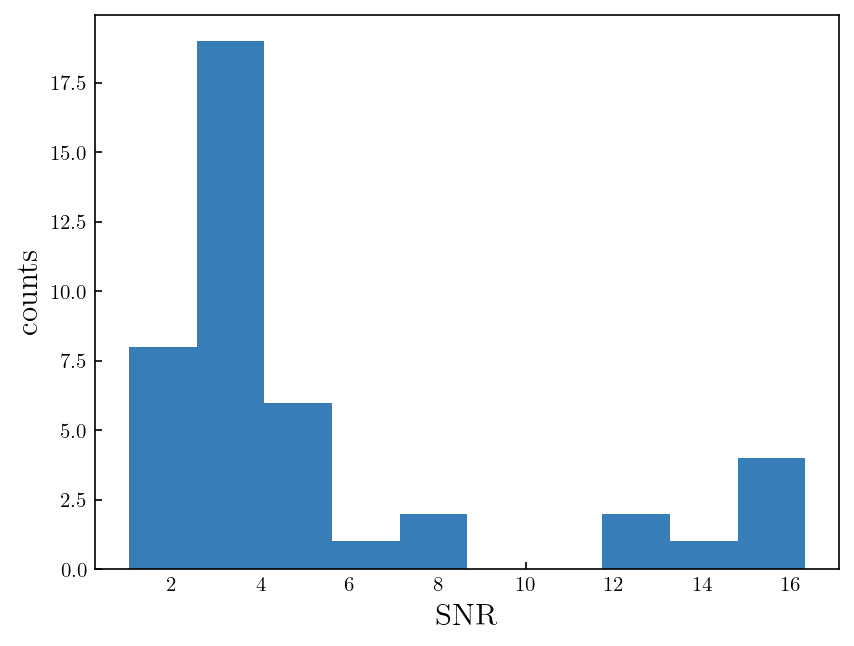

In [12]:
snr = line_df.apply(lambda r: SNR(r['flux'], r['fluxerr']).value, axis=1)
plt.hist(snr)
plt.ylabel('counts')
plt.xlabel('SNR')
plt.show()

In [13]:
all_df_pruned = pd.concat([blue_df_peak, line_df_peak, red_df_peak])

In [14]:
del all_df, line_df, line_df_cut, line_df_peak, blue_df, blue_df_cut, blue_df_peak, red_df, red_df_cut, red_df_peak

In [15]:
wanted = {'[1,4]', '[0,2]', '[1,7]'}#, '[4,4]'}
BIC_df = all_df_pruned[all_df_pruned['transition'].astype(str).str.replace(' ', '').isin(wanted)].copy()
#BIC_df = line_df_coadded_peak[line_df_coadded_peak['transition'].astype(str).str.replace(' ', '').isin(wanted)].copy()
print(len(BIC_df))
BIC_percentile = (BIC_df['BIC1'] - BIC_df['BIC2'])/BIC_df['BIC1']
BIC_conf = BIC_df[(BIC_percentile<=0.25) & (BIC_percentile>0)]
print(len(BIC_conf))
BIC_diff = all_df_pruned[all_df_pruned['BIC2']<all_df_pruned['BIC1']]
print(len(BIC_diff))

28
18
26


In [16]:
#BIC_conf.to_pickle(os.path.join('data','conf_lines.pkl'))

# Collate narrow and broad components

In [17]:
def sort_BC(df):
    double_gauss_params = df['params2']

    both_BC1 = []
    both_BC2 = []

    for param_dict in double_gauss_params:
        wider = param_dict['sig1'] > param_dict['sig2'] # if gauss1 is broader it will be true
        dimmer = param_dict['amp1'] < param_dict['amp2'] # if gauss1 is dimmer it will be true
        both_BC1.append(wider == True and dimmer == True) # Usually true, frequently not
        both_BC2.append(wider == False and dimmer == False)
        
    both_BC1 = np.array(both_BC1)
    both_BC2 = np.array(both_BC2)

    BC_1_definitely = df[both_BC1]
    BC_2_definitely = df[both_BC2]

    #now only consider unsure lines
    #lines where both is false is unsure
    unsure = df.iloc[np.argwhere((both_BC1 == False) & (both_BC2 == False)).ravel()]
    if len(unsure)>0:
        wider_1 = []
        for param_dict in unsure['params2']:
            wider = param_dict['sig1'] > param_dict['sig2'] # if gauss1 is broader it will be true
            wider_1.append(wider)
        wider_1 = np.array(wider_1)

        BC_1_maybe = unsure[wider_1]
        BC_2_maybe = unsure[~wider_1]
    else:
        BC_1_maybe = None
        BC_2_maybe = None

    return BC_1_definitely, BC_2_definitely, BC_1_maybe, BC_2_maybe

In [18]:
BC_1_conf, BC_2_conf, conf_maybe1, conf_maybe2 = sort_BC(BIC_conf.copy())
BC_1_diff, BC_2_diff, diff_maybe1, diff_maybe2 = sort_BC(BIC_diff.copy())

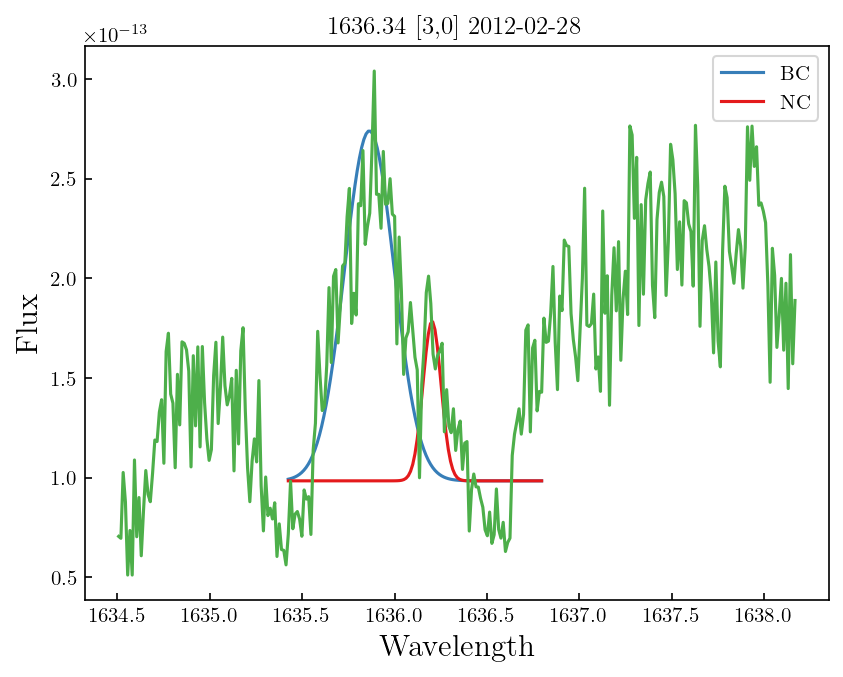

In [19]:
#examine fits that are unsure
for i, row in diff_maybe1.iterrows():
    x = row['conv_wavelength']
    gauss1, gauss2 = make_gauss_from_params(x, row['params2'])
    plt.plot(x, gauss1, label='BC')
    plt.plot(x, gauss2, label='NC')
    plt.plot(row['wavelength'], row['flux'])
    plt.xlabel('Wavelength')
    plt.ylabel('Flux')
    plt.title(str(row['labline']) + ' ' + str(row['transition']) + ' ' + str(row['obsdate']))
    plt.legend()
    plt.show()

In [20]:
#collate all broad component params and NC params separately, do manually for maybes

BC_1_conf['BC_params'] = BC_1_conf['params2'].apply(
                                                    lambda p: {
                                                        'ampBC': p['amp1'],
                                                        'sigBC': p['sig1'],
                                                        'cenBC': p['cen1'],
                                                        'bgl': p['bgl']
                                                    }
                                                )
BC_1_conf['NC_params'] = BC_1_conf['params2'].apply(
                                                    lambda p: {
                                                        'ampNC': p['amp2'],
                                                        'sigNC': p['sig2'],
                                                        'cenNC': p['cen2'],
                                                        'bgl': p['bgl']
                                                    }
                                                )

BC_2_conf['BC_params'] = BC_2_conf['params2'].apply(
                                                    lambda p: {
                                                        'ampBC': p['amp2'],
                                                        'sigBC': p['sig2'],
                                                        'cenBC': p['cen2'],
                                                        'bgl': p['bgl']
                                                    }
                                                )
BC_2_conf['NC_params'] = BC_2_conf['params2'].apply(
                                                    lambda p: {
                                                        'ampNC': p['amp1'],
                                                        'sigNC': p['sig1'],
                                                        'cenNC': p['cen1'],
                                                        'bgl': p['bgl']
                                                    }
                                                )
BC_conf = pd.concat([BC_1_conf, BC_2_conf])

In [21]:
BC_1_diff['BC_params'] = BC_1_diff['params2'].apply(
                                                    lambda p: {
                                                        'ampBC': p['amp1'],
                                                        'sigBC': p['sig1'],
                                                        'cenBC': p['cen1'],
                                                        'bgl': p['bgl']
                                                    }
                                                )
BC_1_diff['NC_params'] = BC_1_diff['params2'].apply(
                                                    lambda p: {
                                                        'ampNC': p['amp2'],
                                                        'sigNC': p['sig2'],
                                                        'cenNC': p['cen2'],
                                                        'bgl': p['bgl']
                                                    }
                                                )

BC_2_diff['BC_params'] = BC_2_diff['params2'].apply(
                                                    lambda p: {
                                                        'ampBC': p['amp2'],
                                                        'sigBC': p['sig2'],
                                                        'cenBC': p['cen2'],
                                                        'bgl': p['bgl']
                                                    }
                                                )
BC_2_diff['NC_params'] = BC_2_diff['params2'].apply(
                                                    lambda p: {
                                                        'ampNC': p['amp1'],
                                                        'sigNC': p['sig1'],
                                                        'cenNC': p['cen1'],
                                                        'bgl': p['bgl']
                                                    }
                                                )
BC_diff = pd.concat([BC_1_diff, BC_2_diff])

# NC BC comparison

## Broad Component

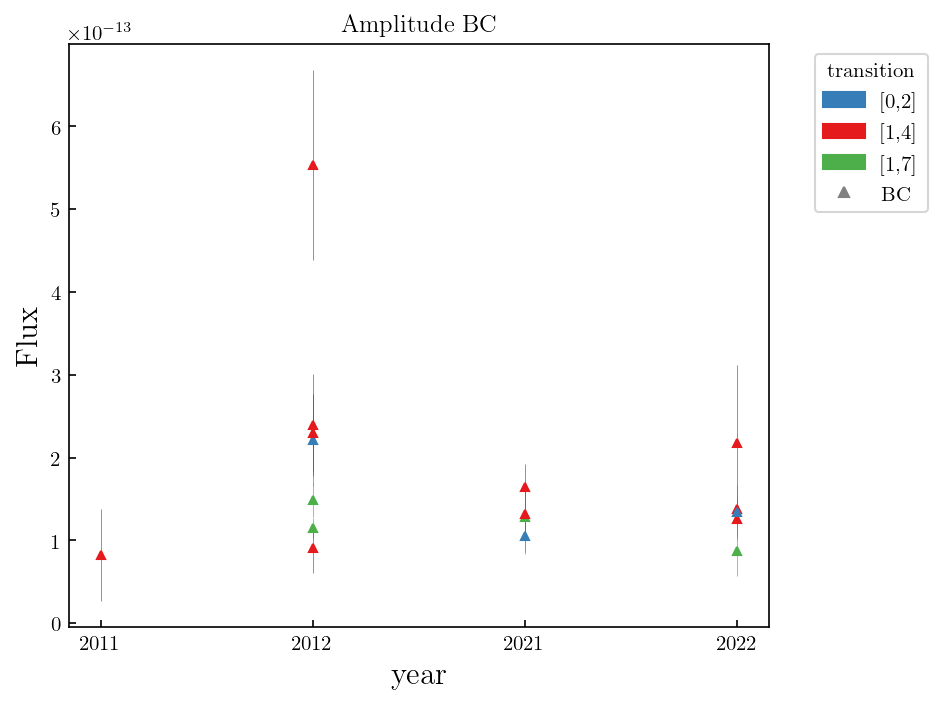

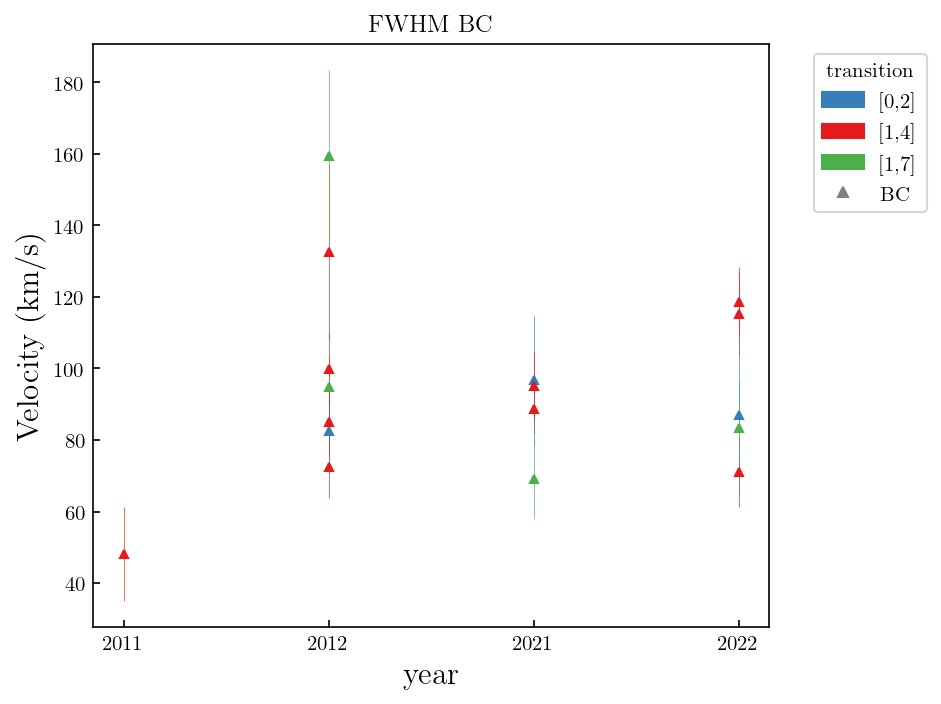

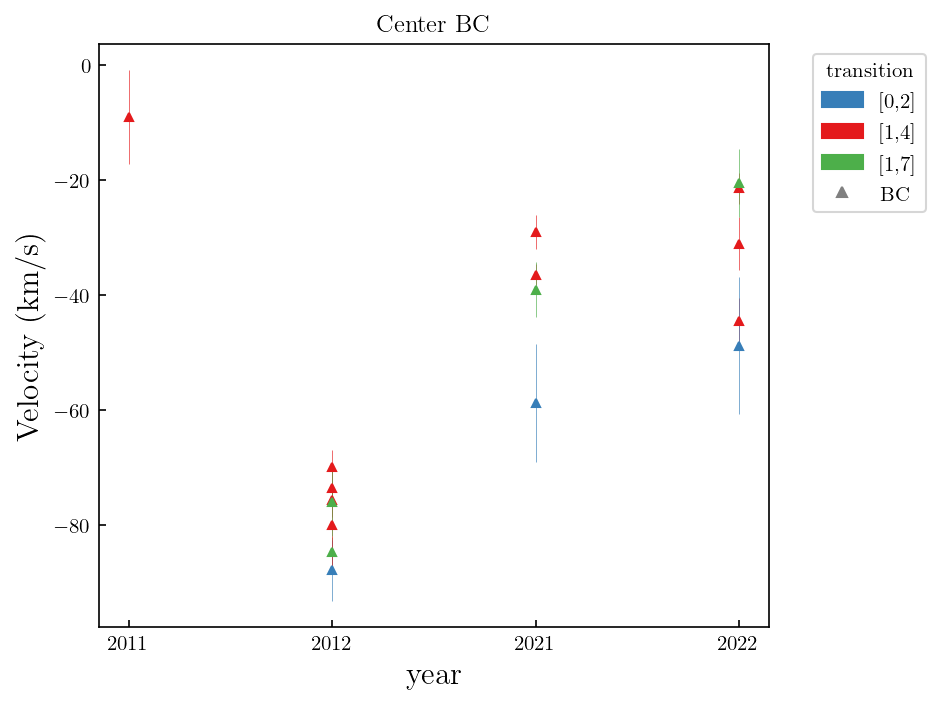

In [31]:
plot_progression(BC_conf, ['BC'])

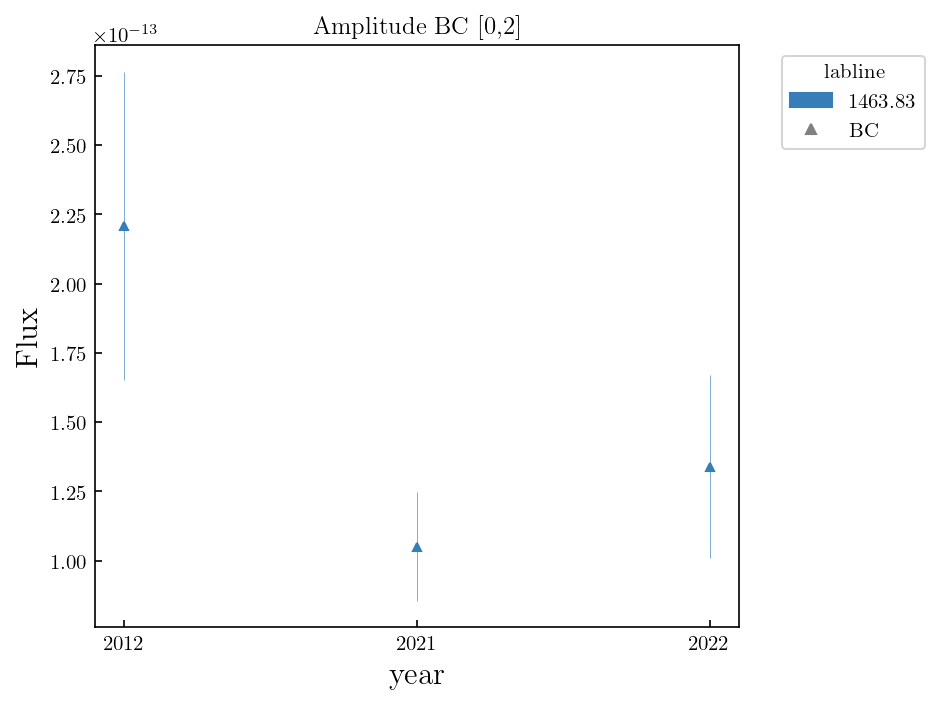

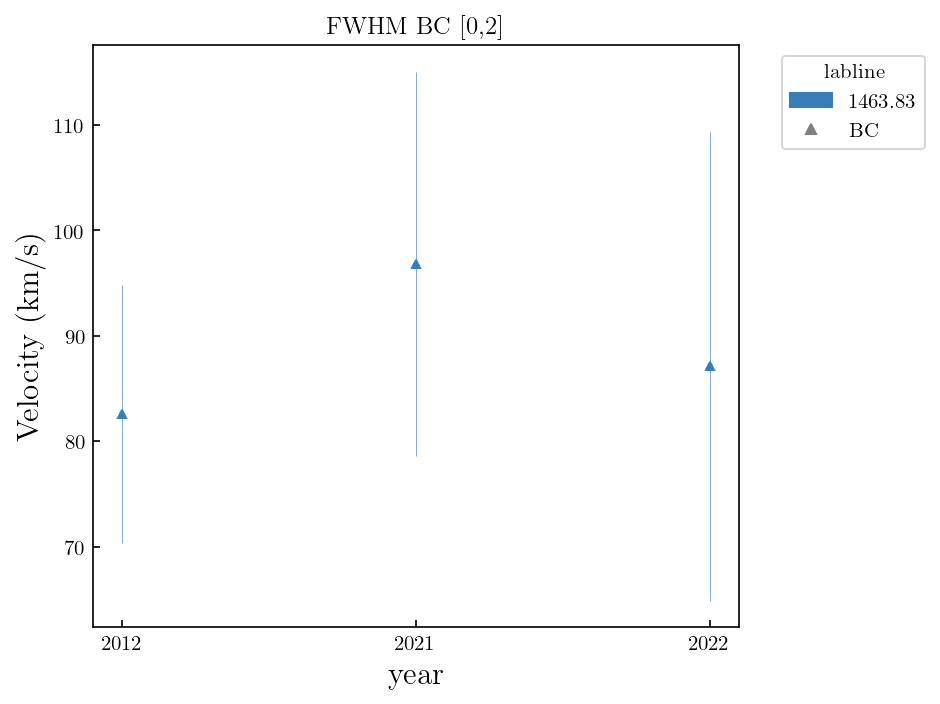

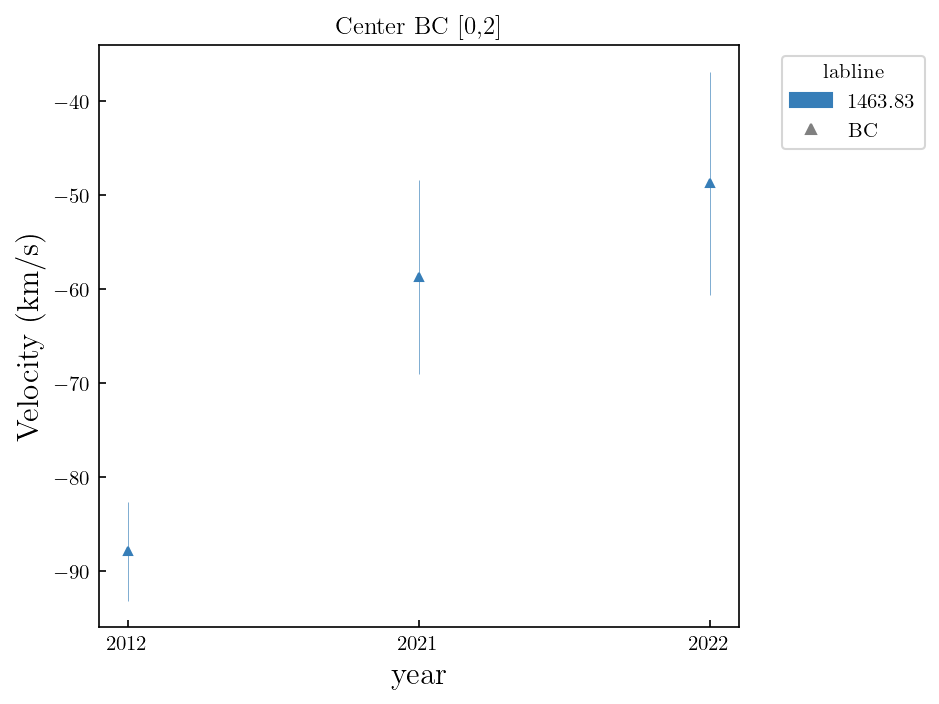

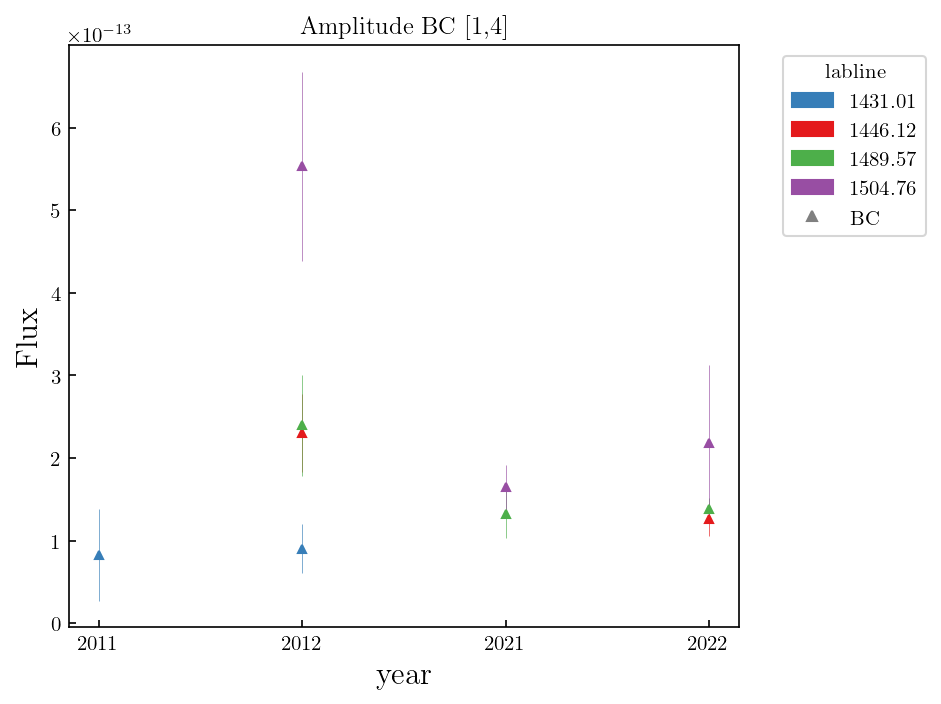

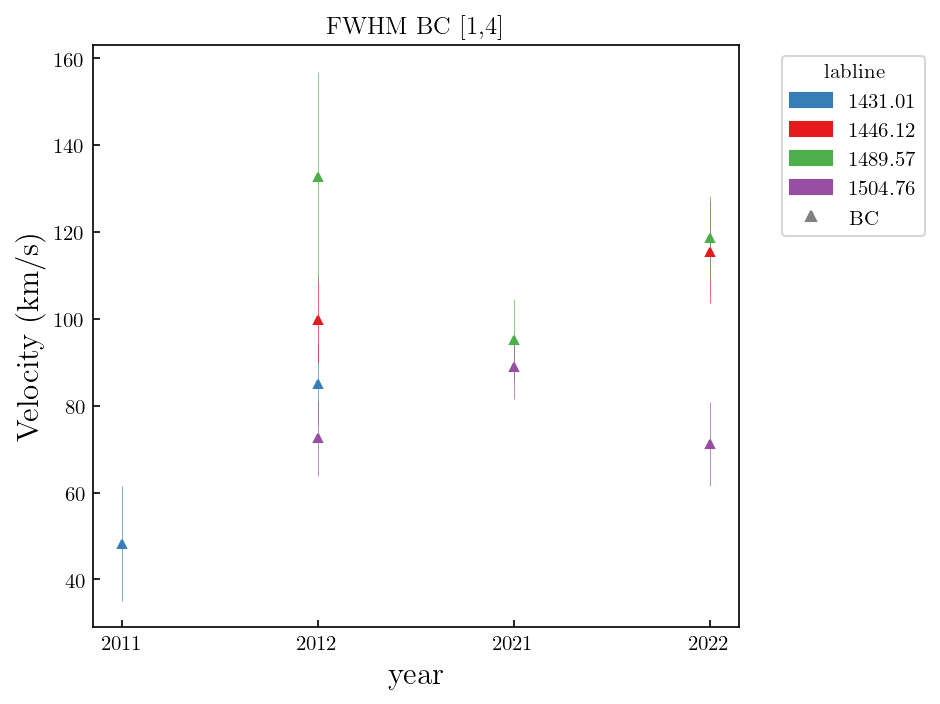

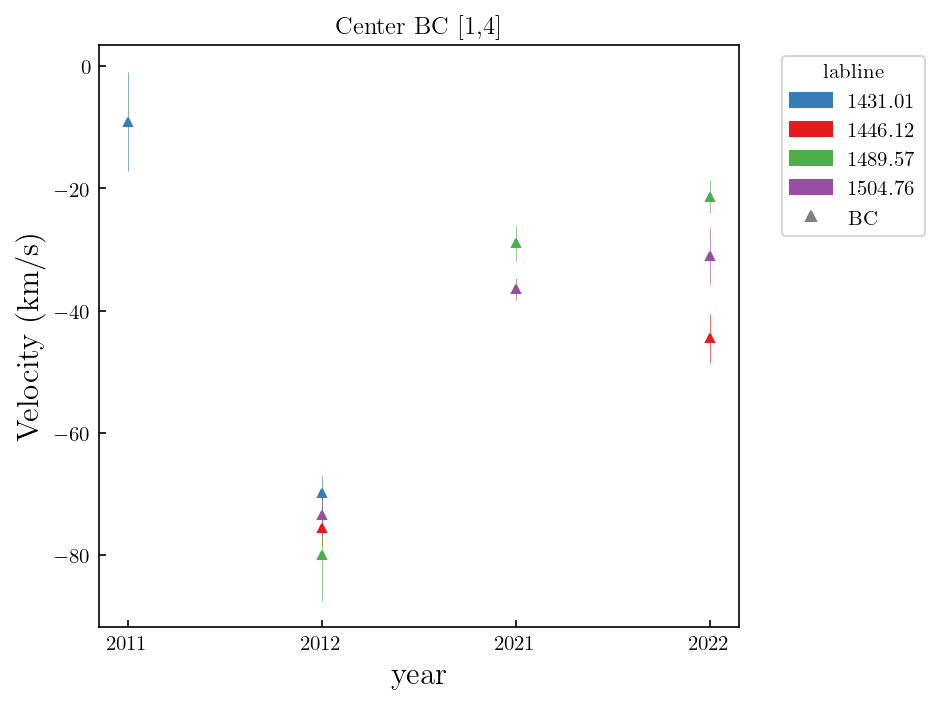

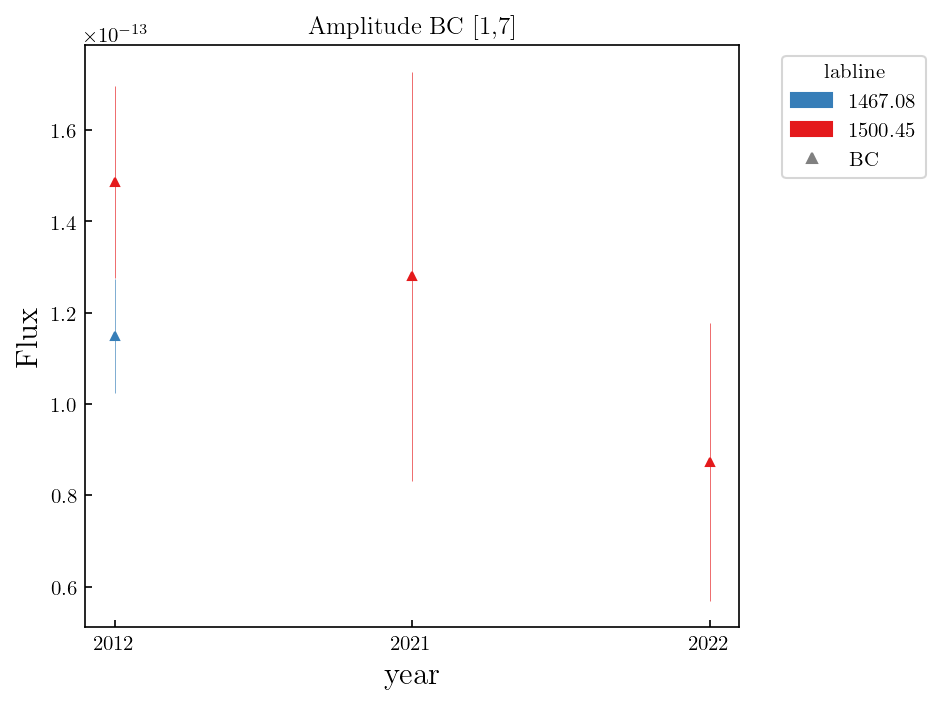

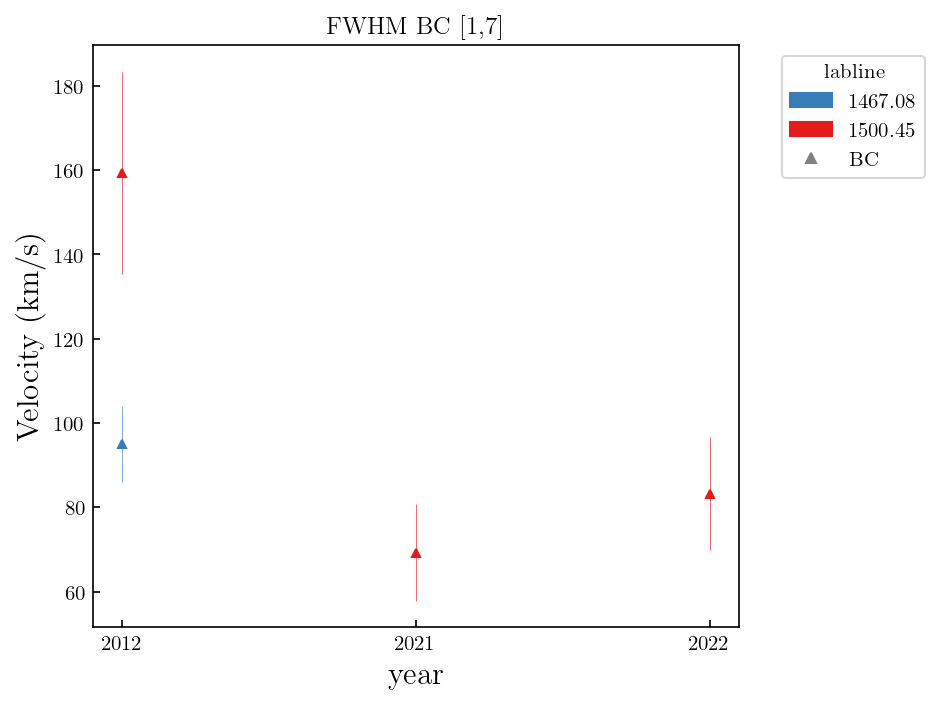

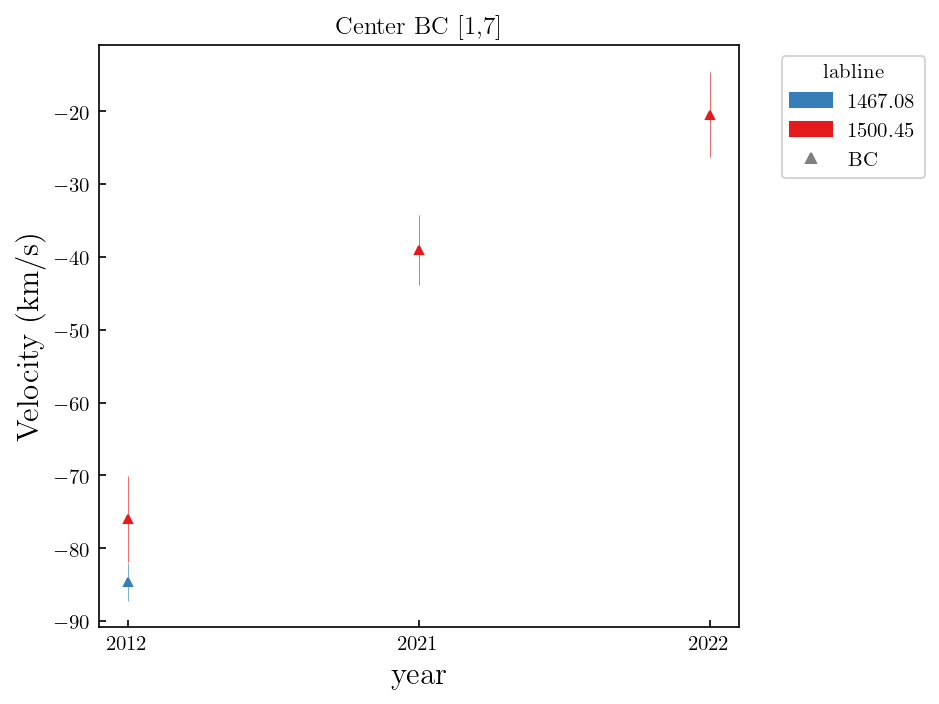

In [32]:
plot_progression_by_transition(BC_conf, ['BC'])

## Narrow Component

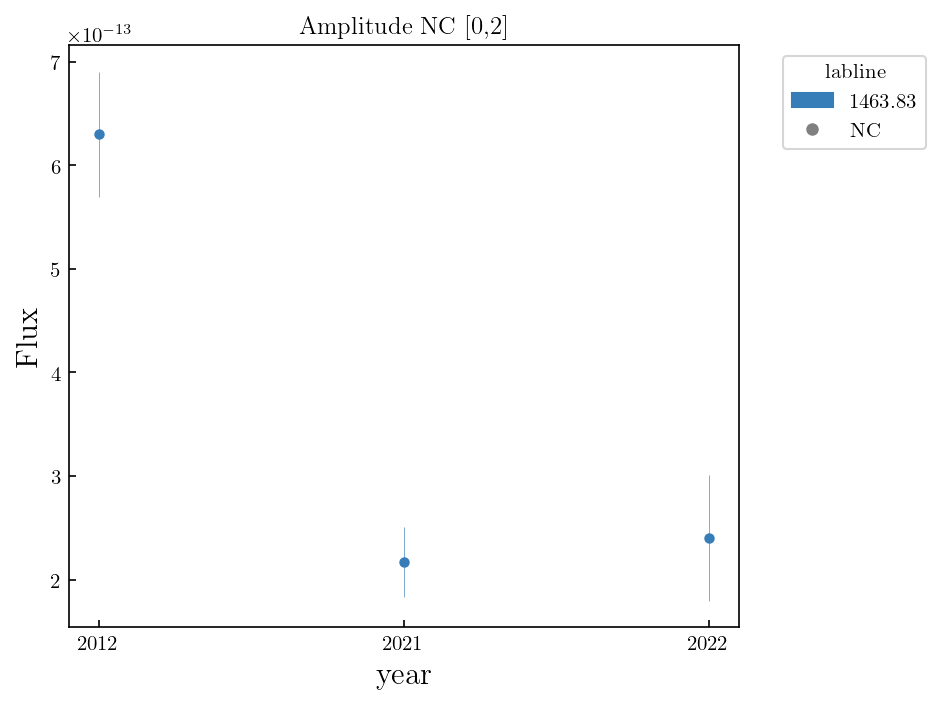

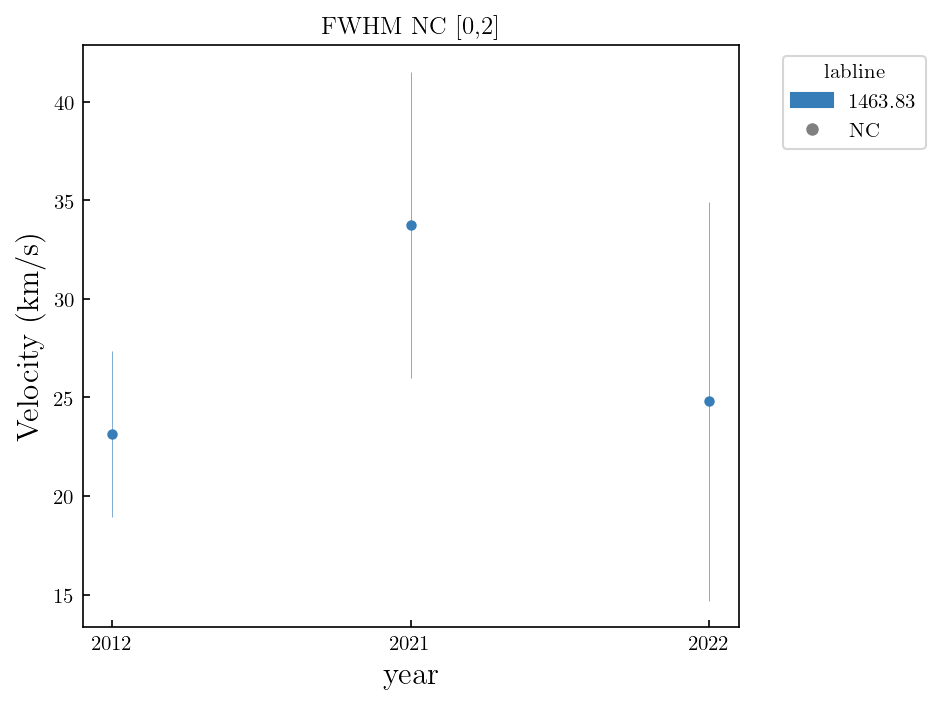

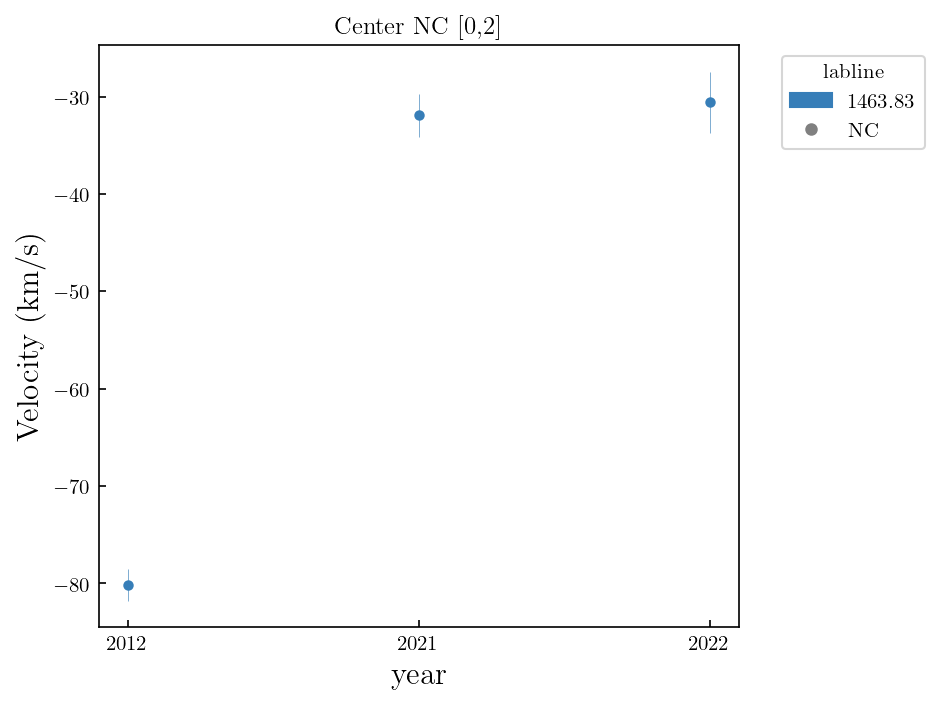

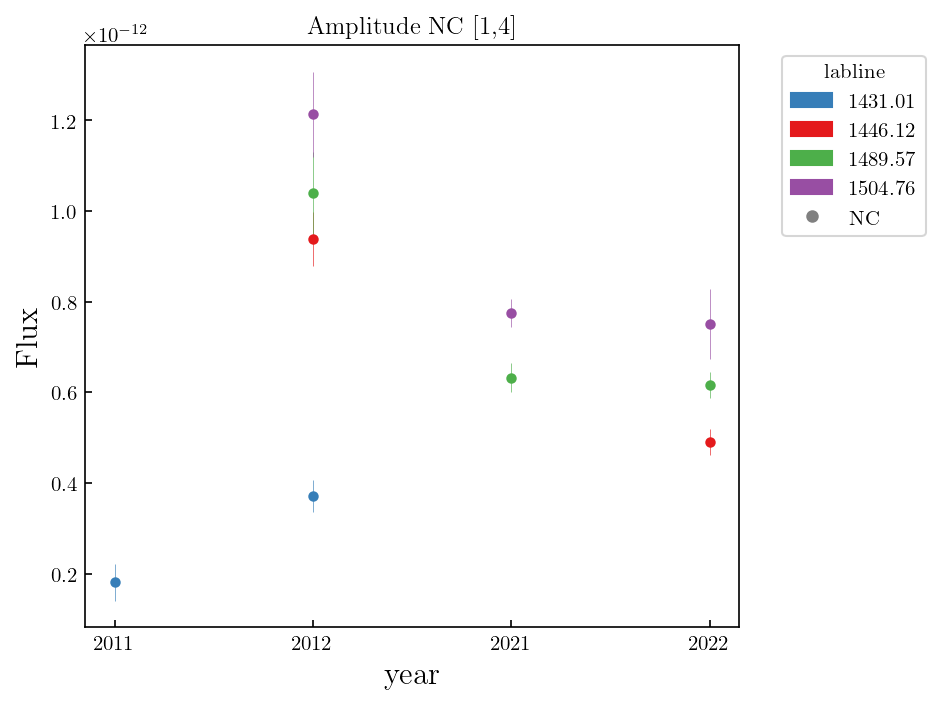

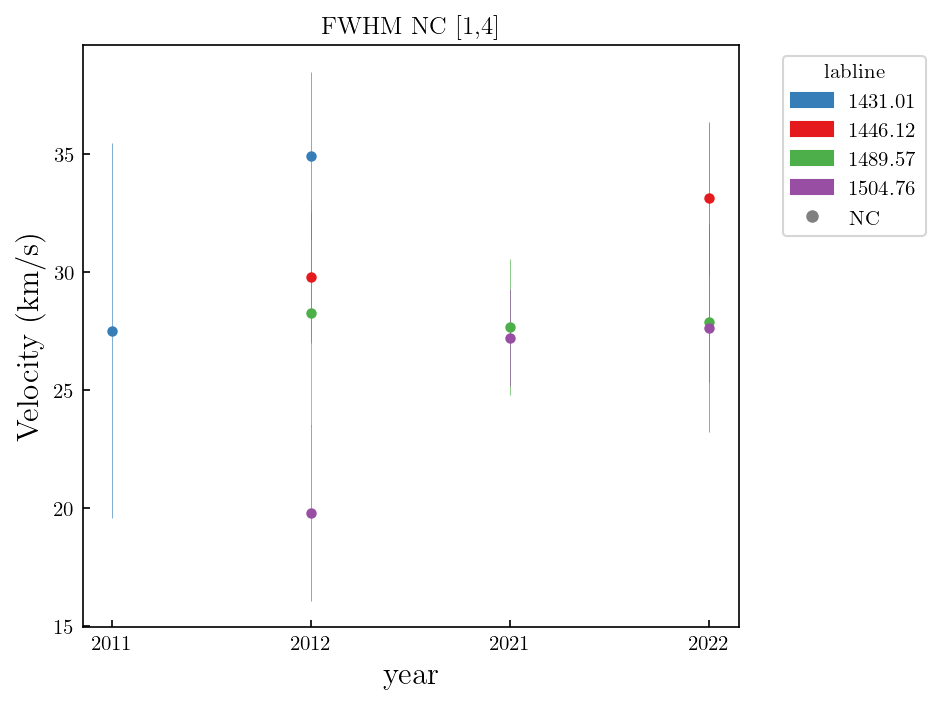

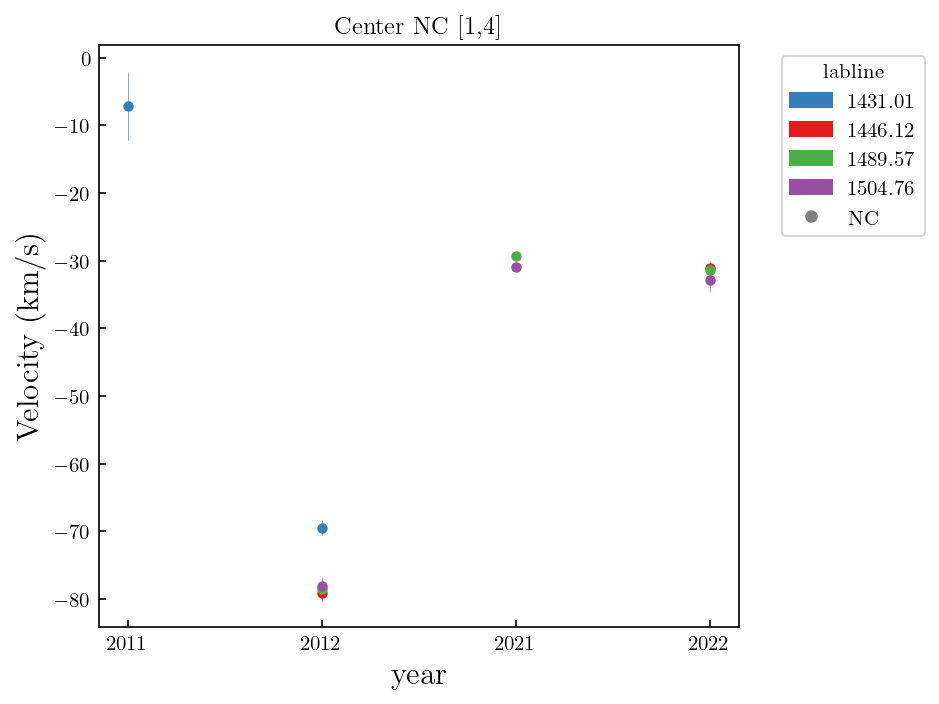

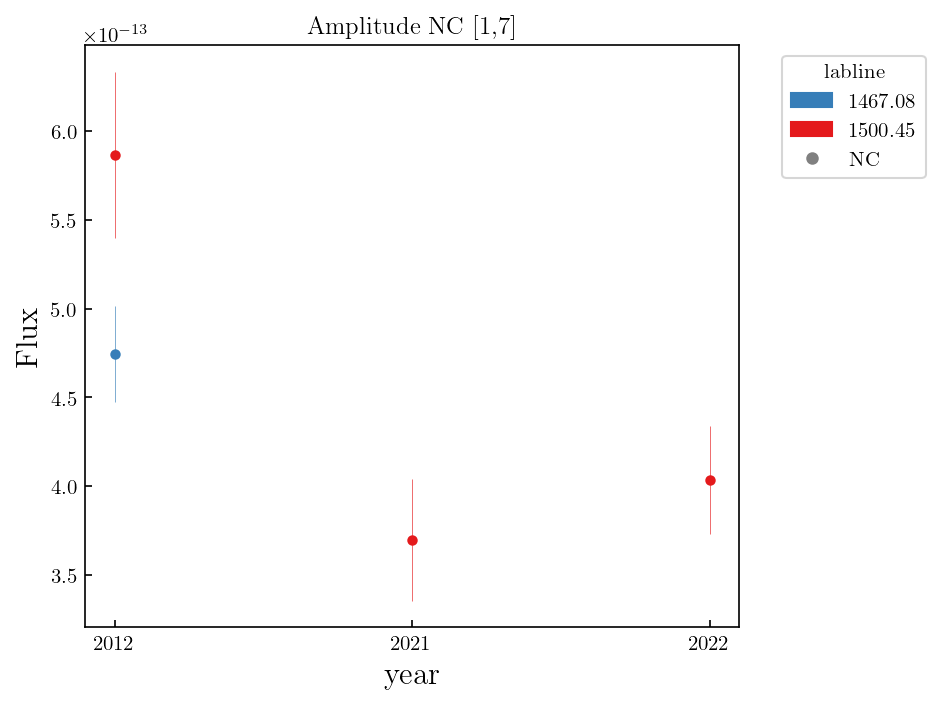

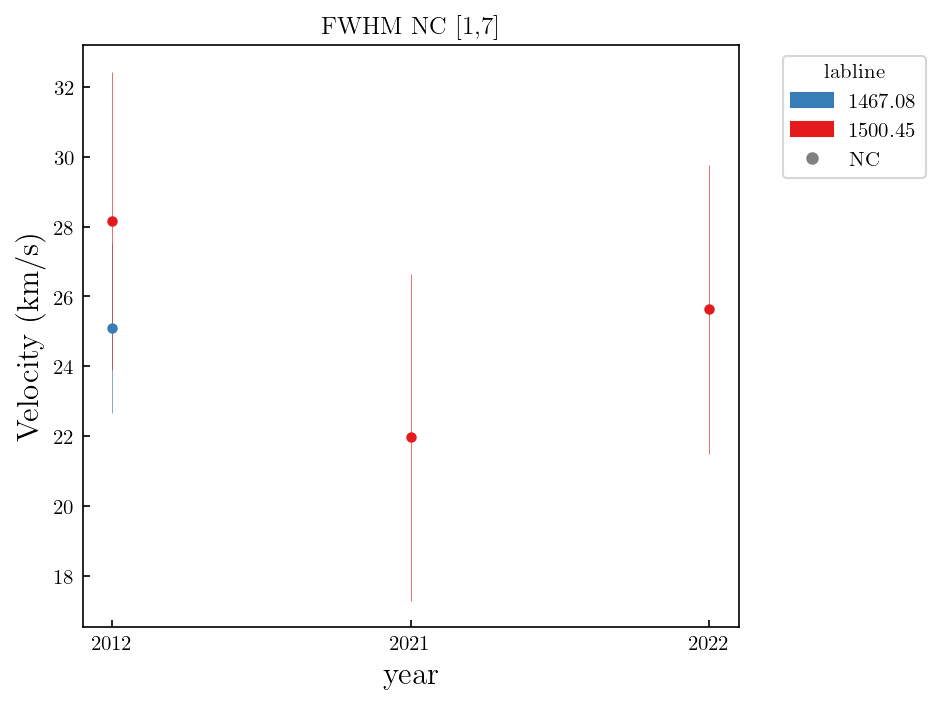

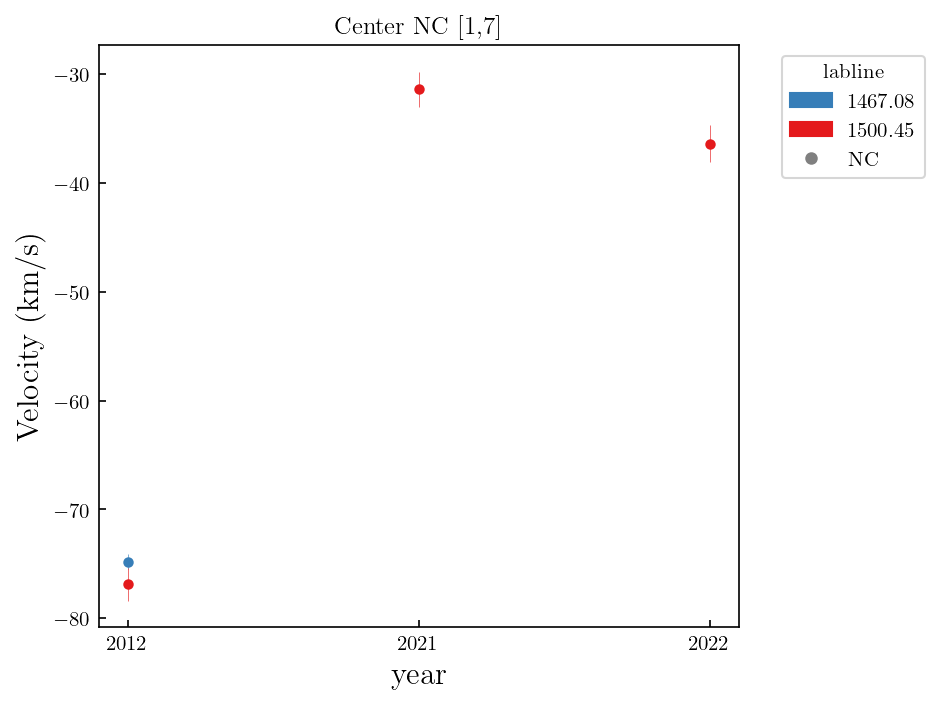

In [33]:
plot_progression_by_transition(BC_conf, ['NC'])

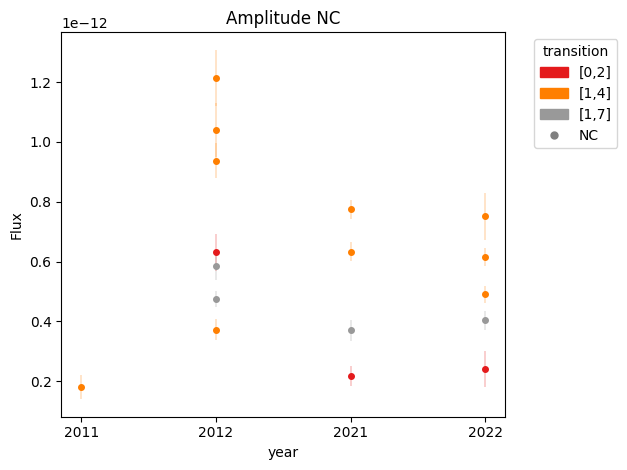

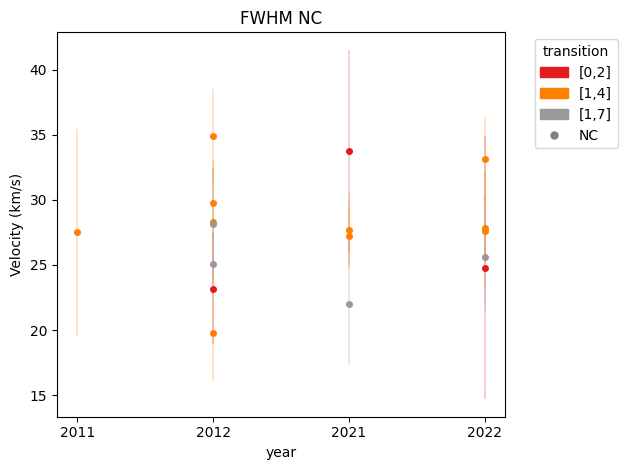

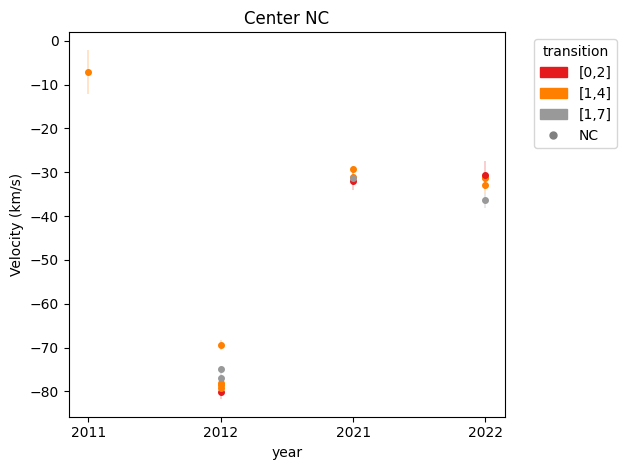

In [29]:
plot_progression(BC_conf, ['NC'])

## Compare NC and single Gauss

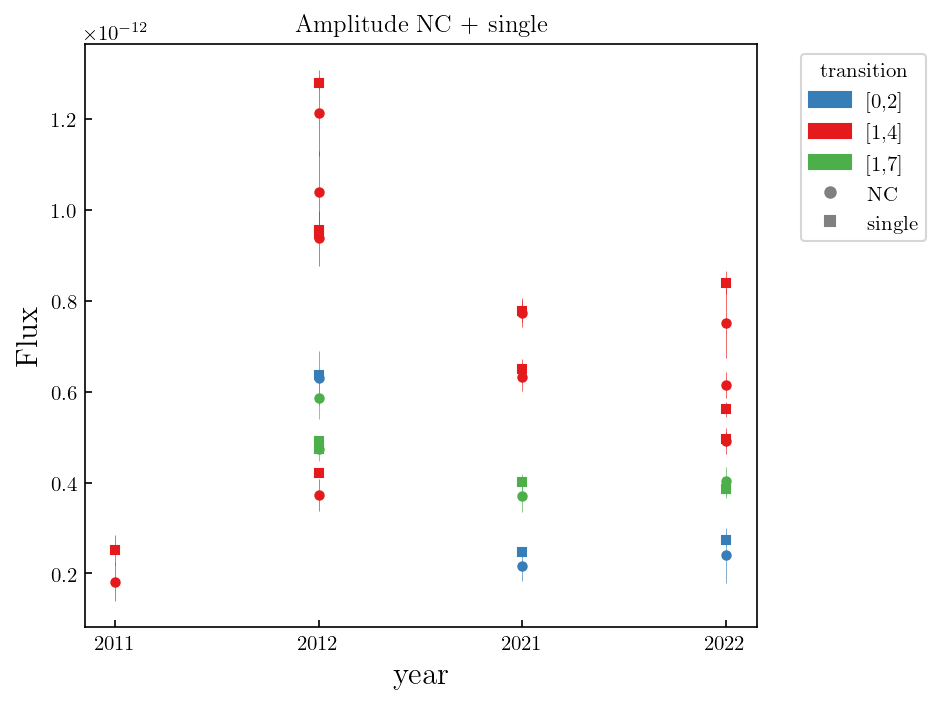

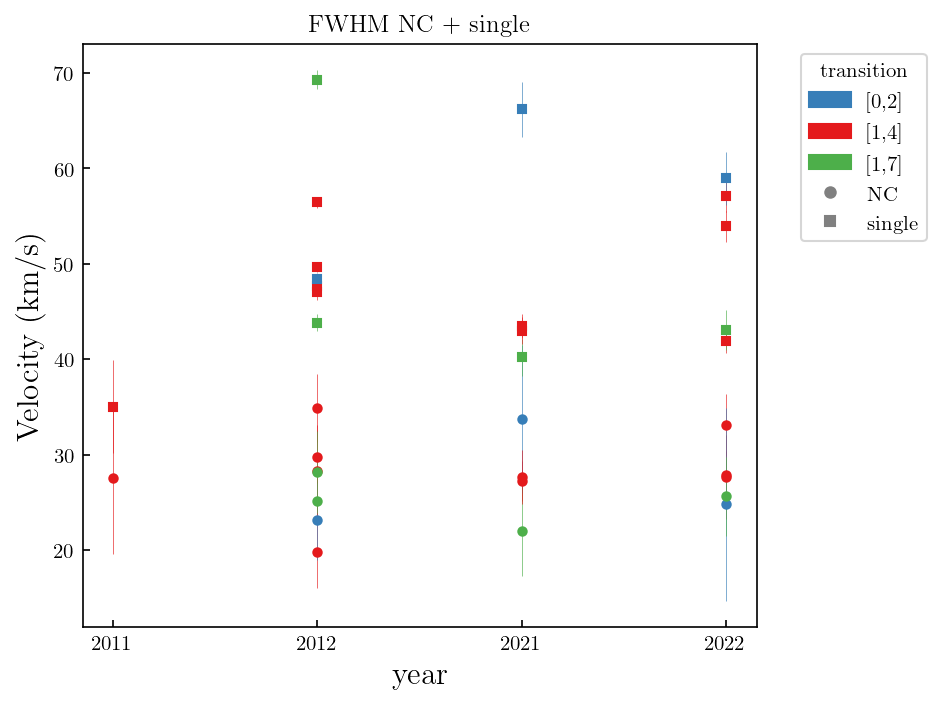

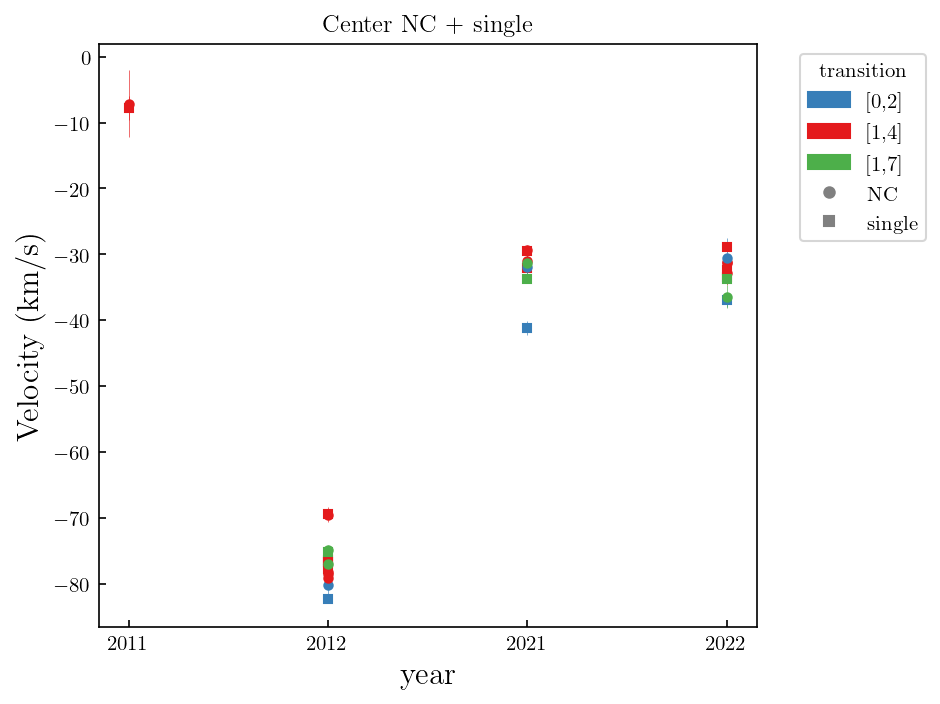

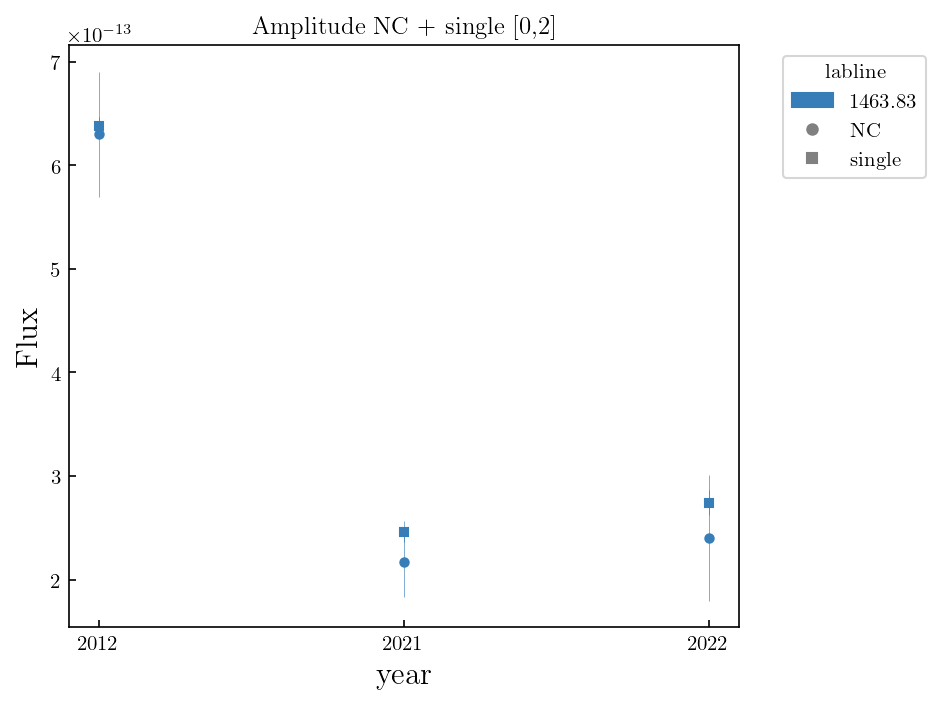

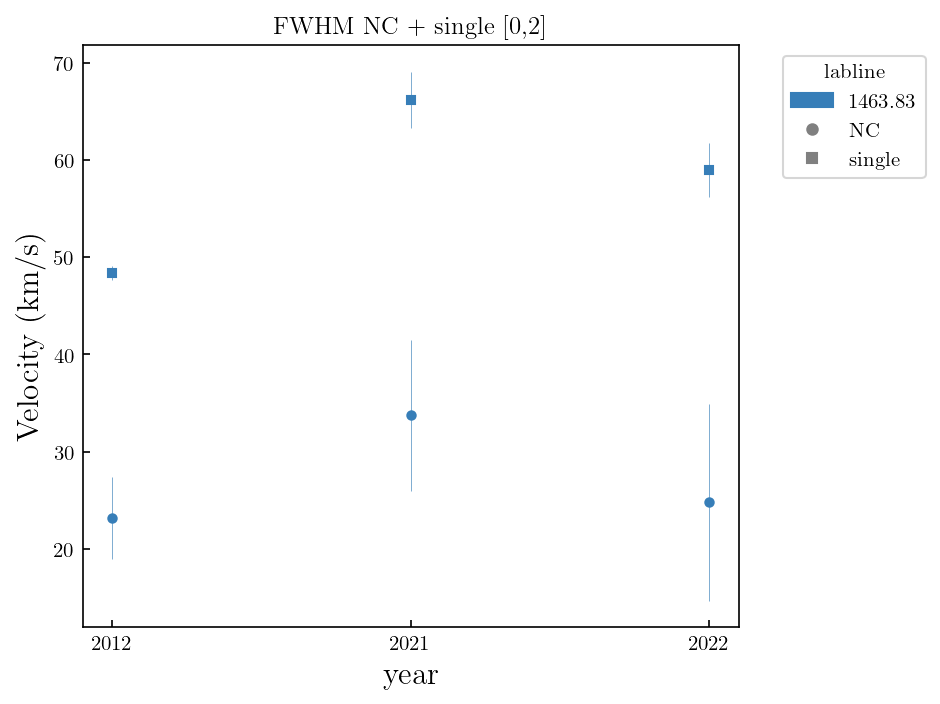

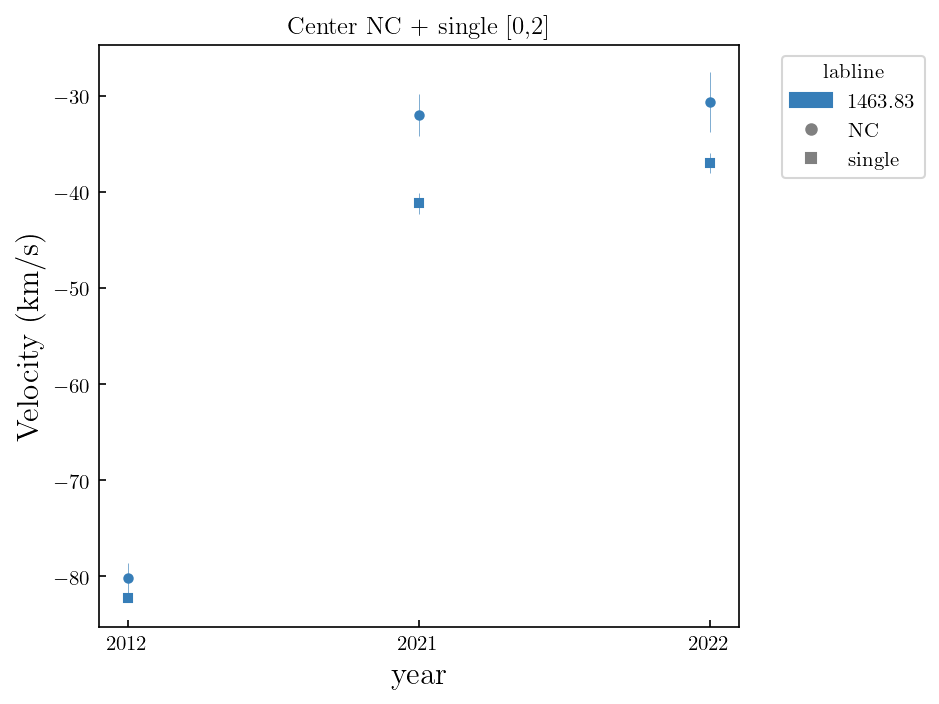

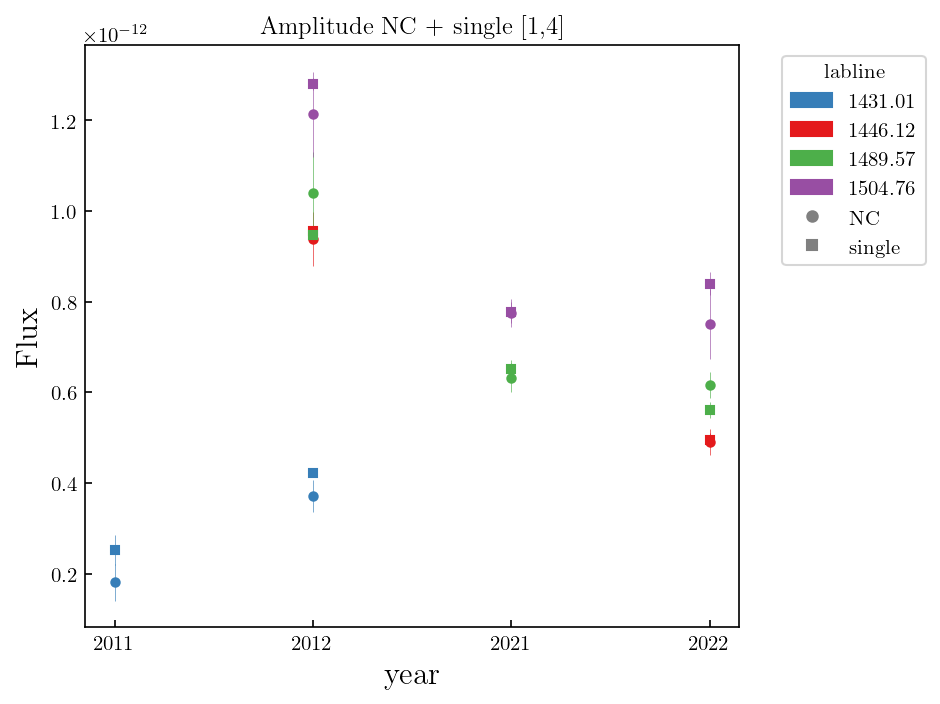

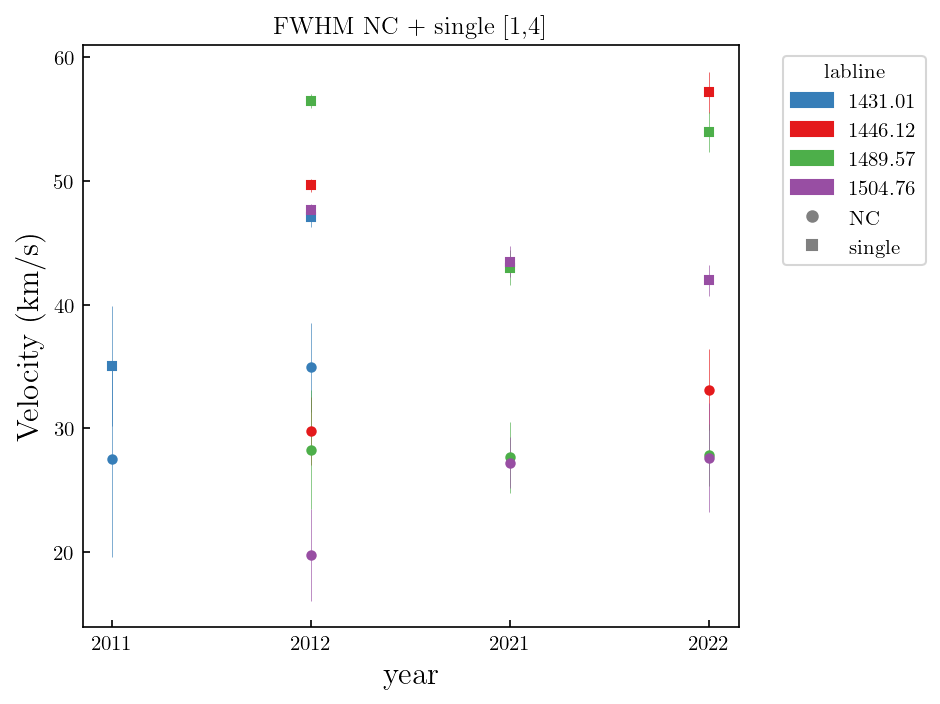

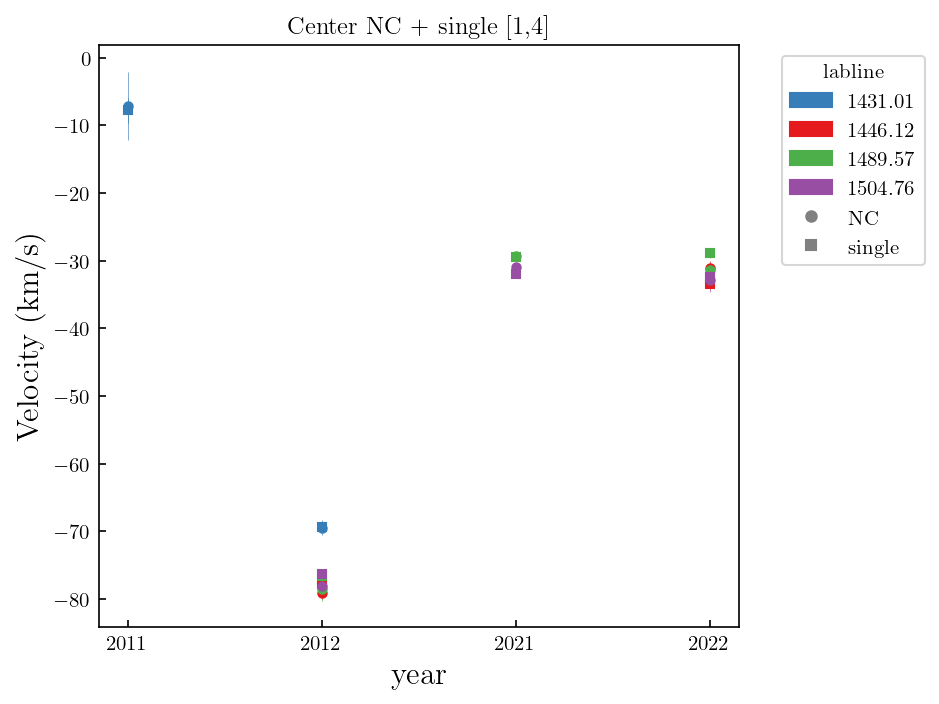

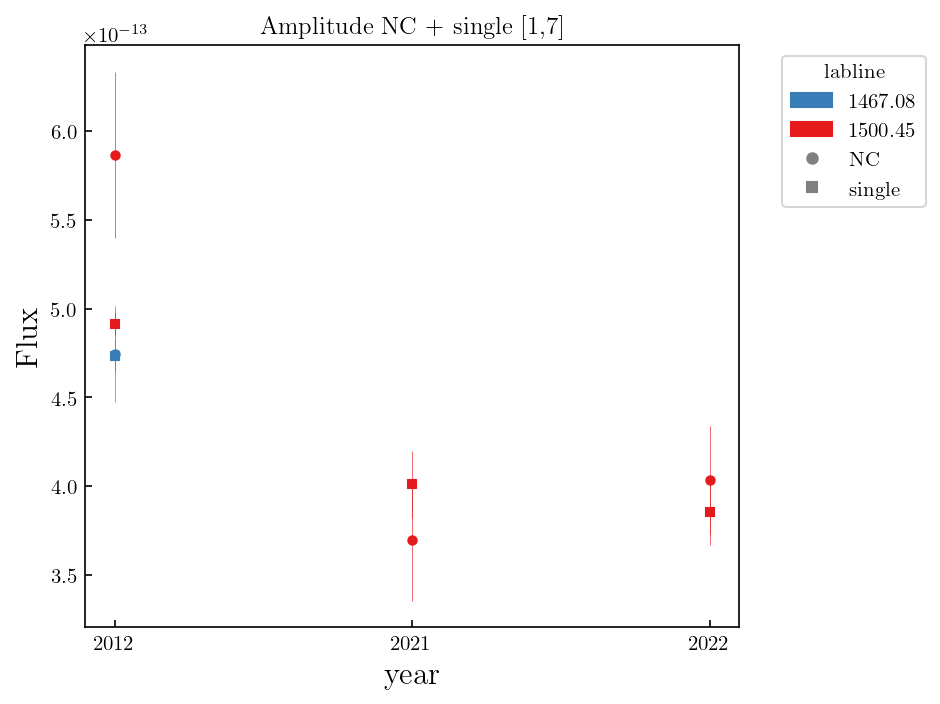

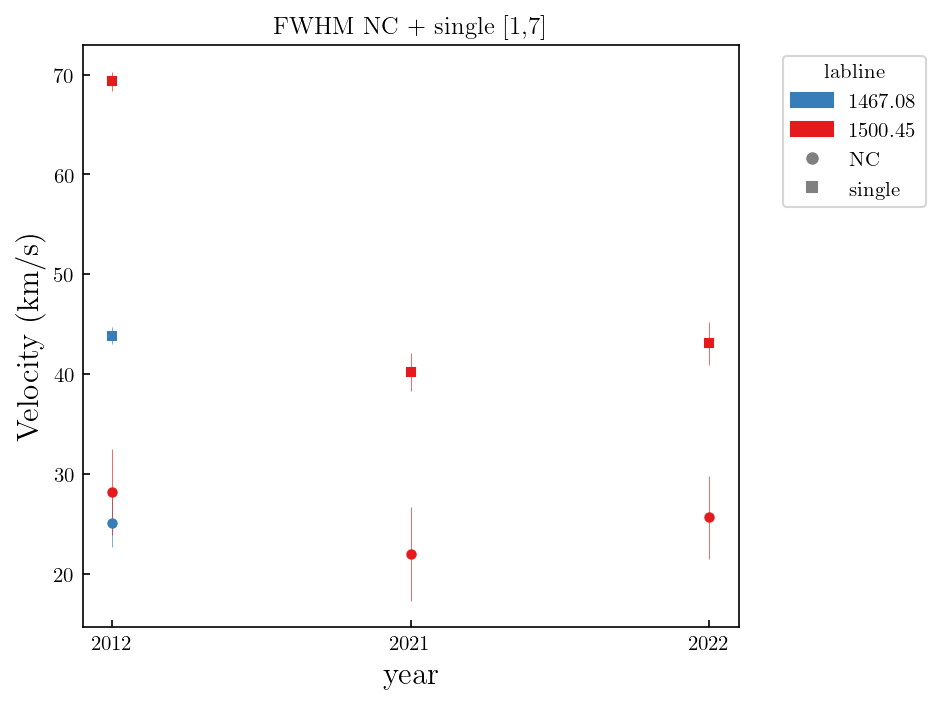

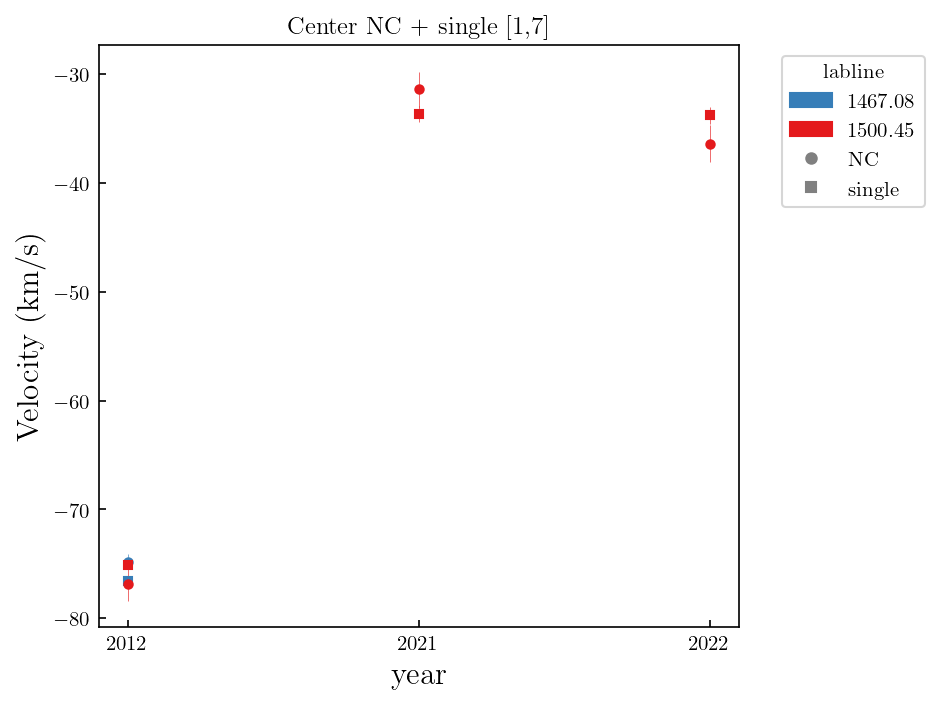

In [37]:
plot_progression(BC_conf, ['NC', 'single'])
plot_progression_by_transition(BC_conf, ['NC', 'single'])

## Other comparisons

In [22]:
SC_transitions = ['[0,2]', '[1,4]', '[1,7]']
SC_df = all_df_pruned[~all_df_pruned['transition'].isin(SC_transitions)]

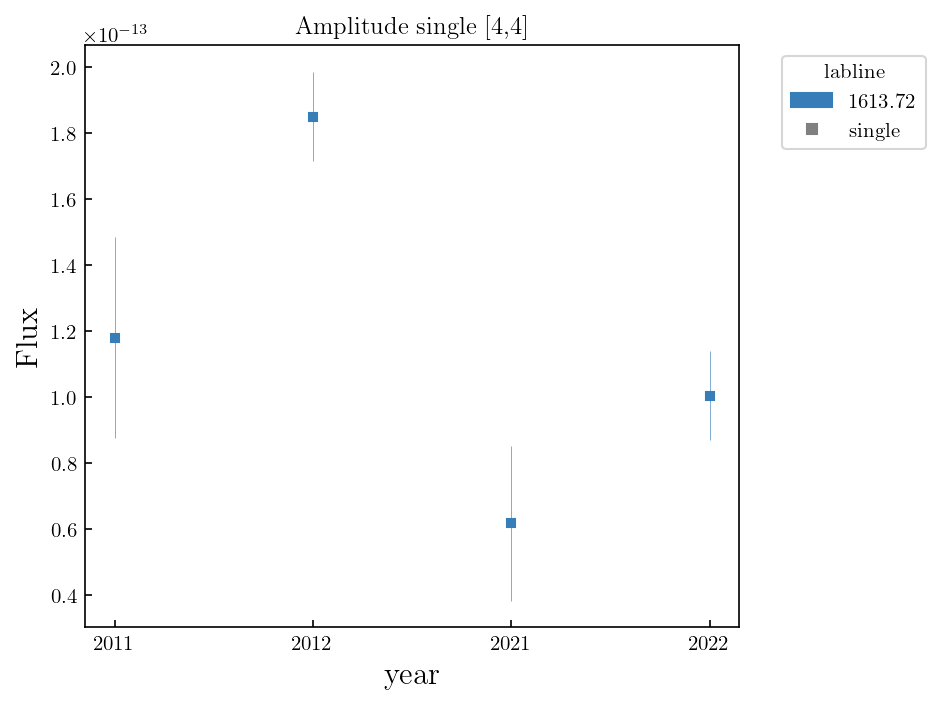

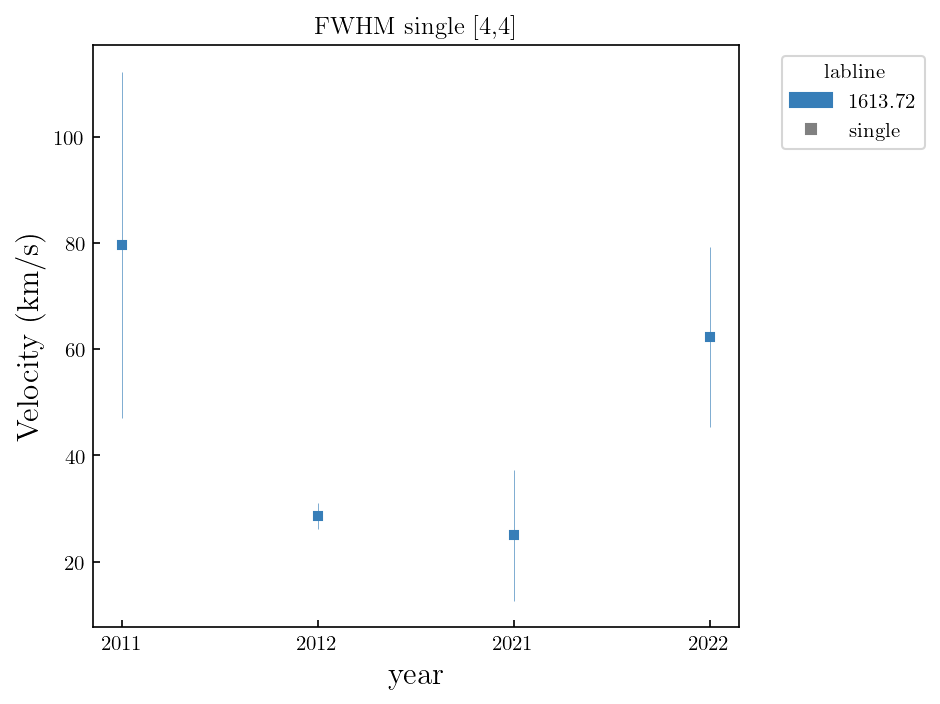

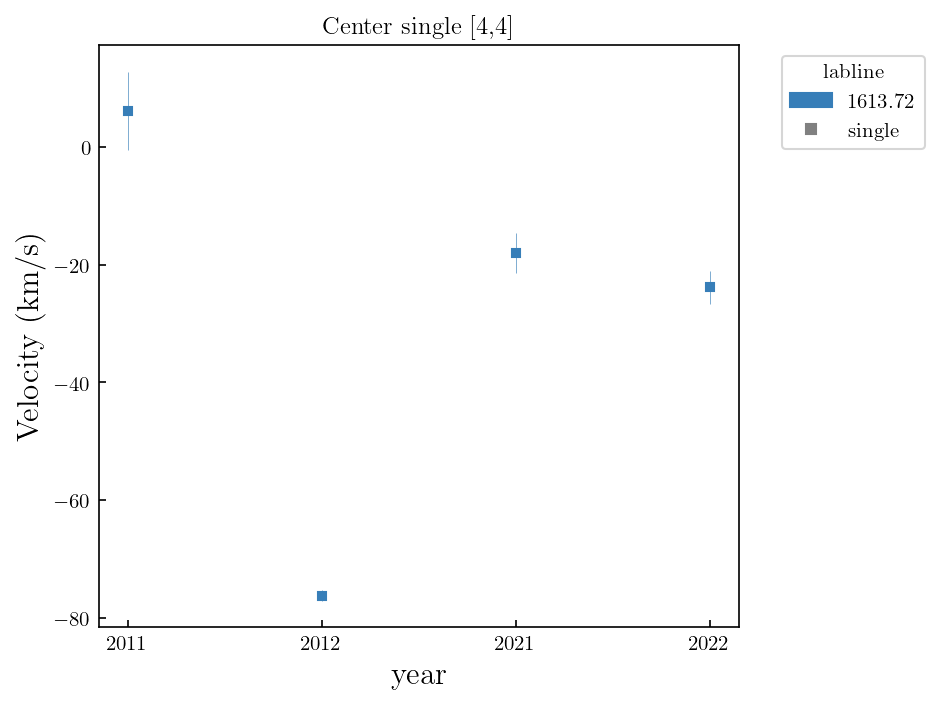

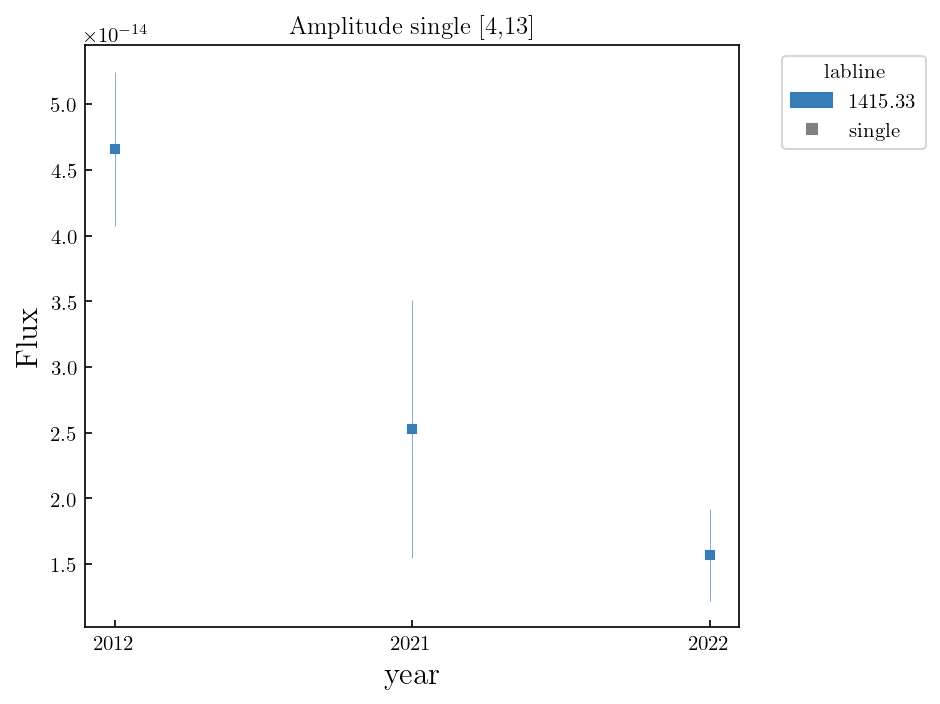

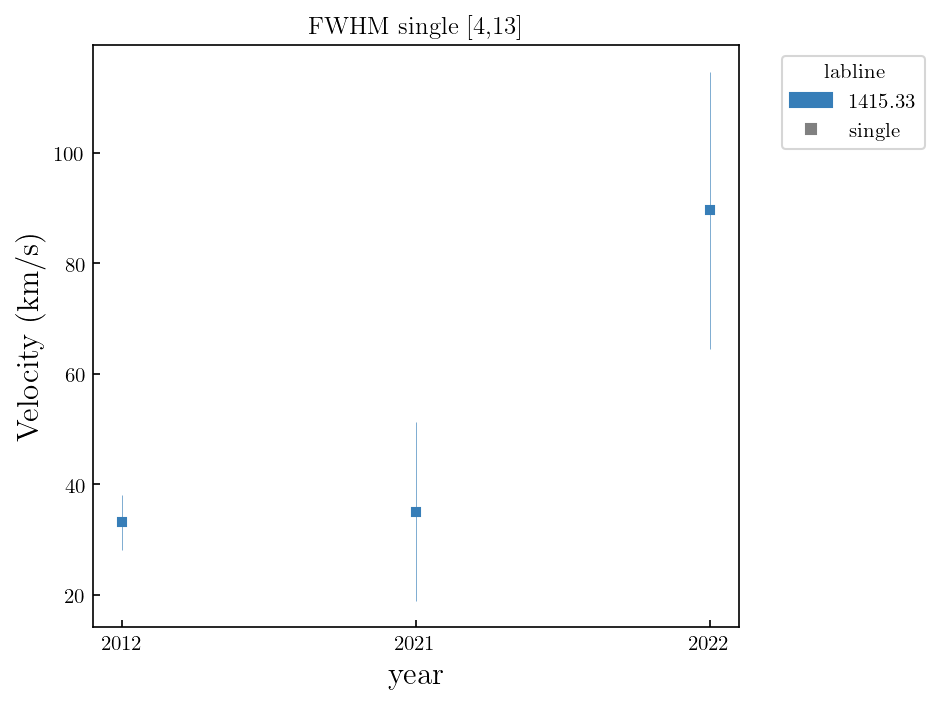

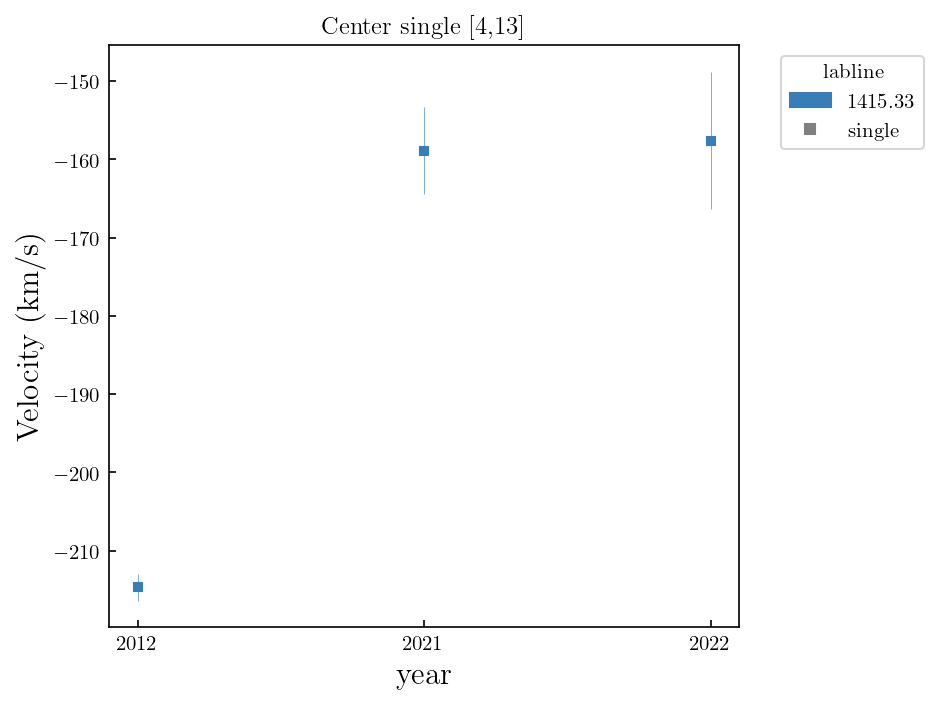

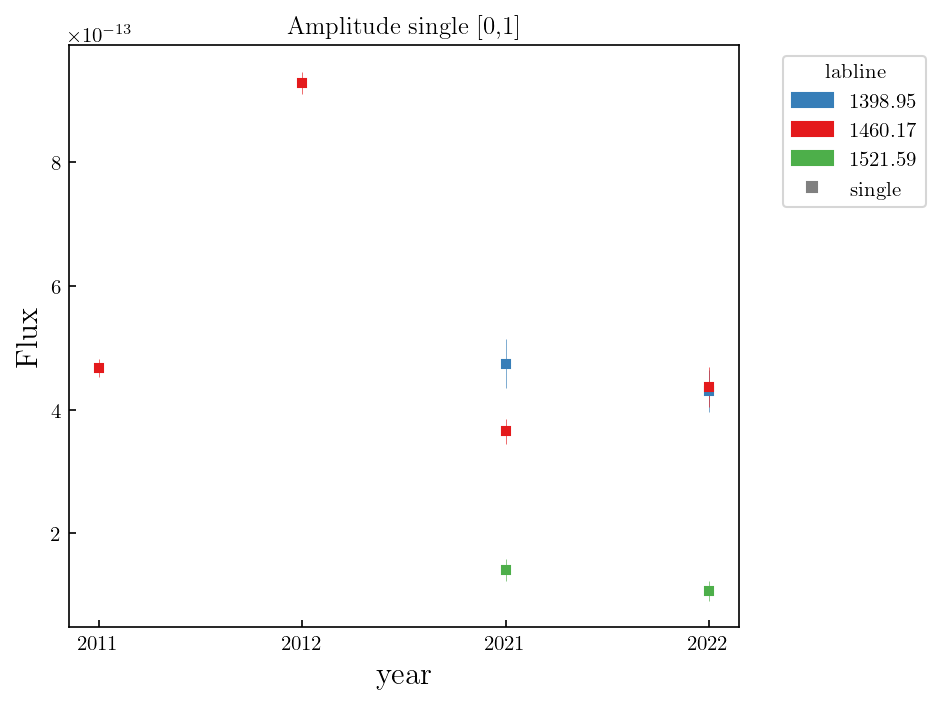

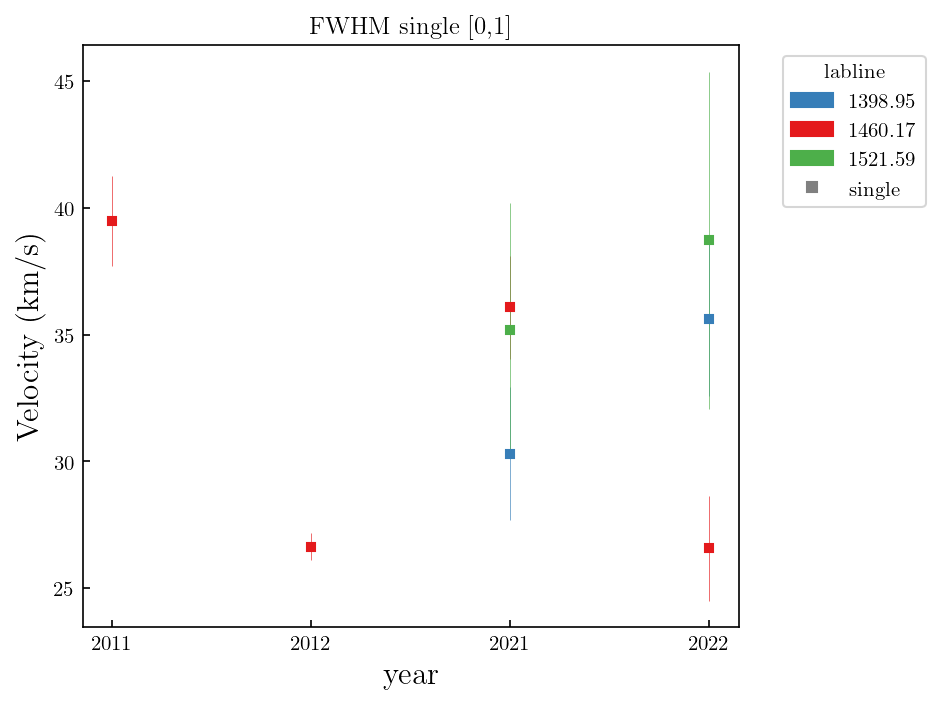

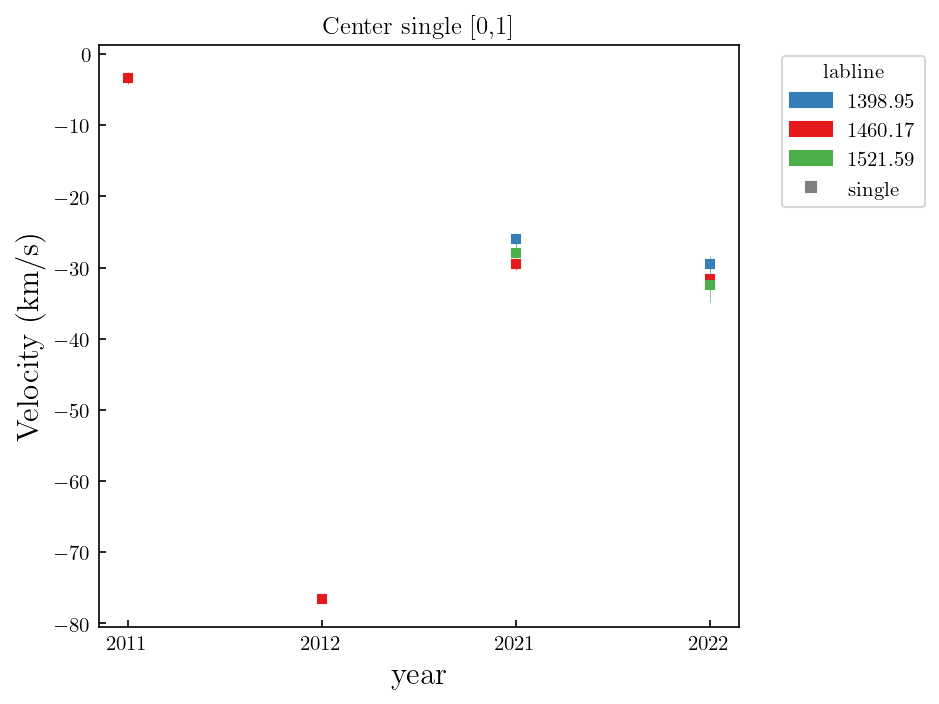

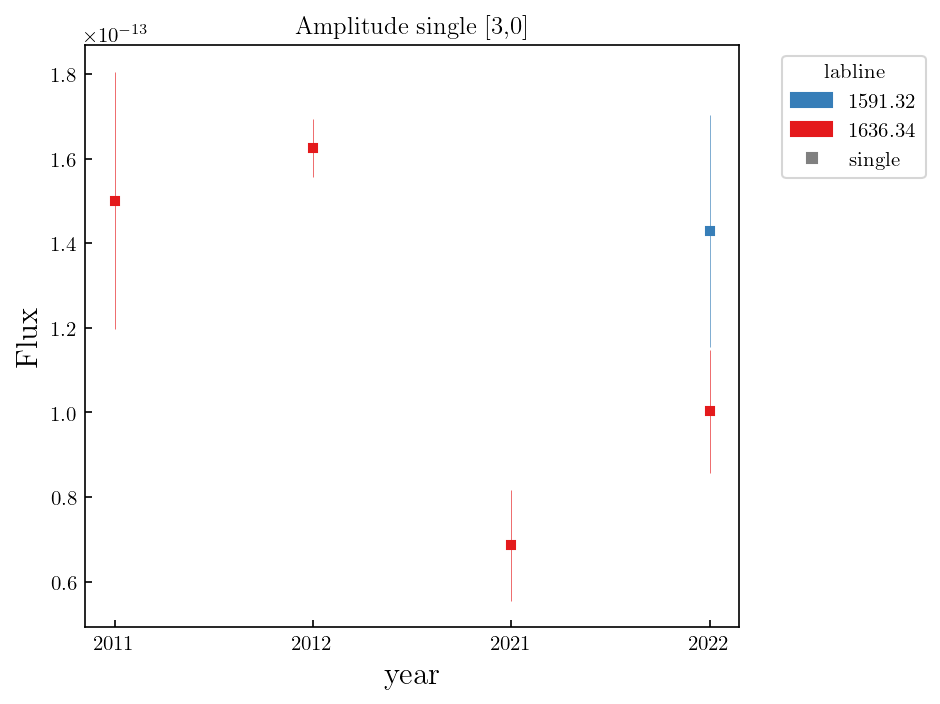

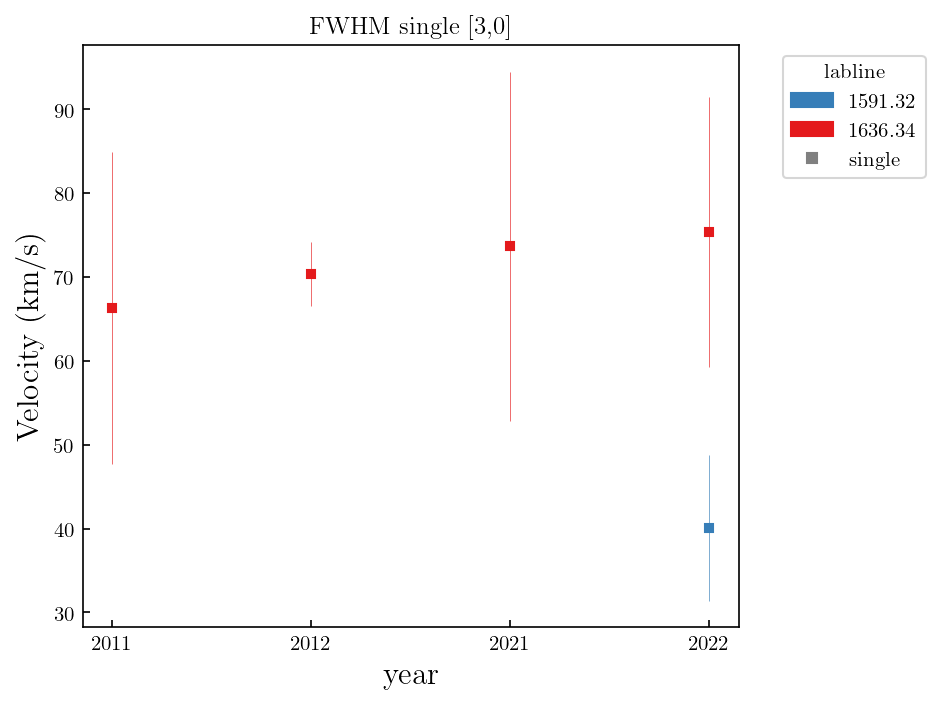

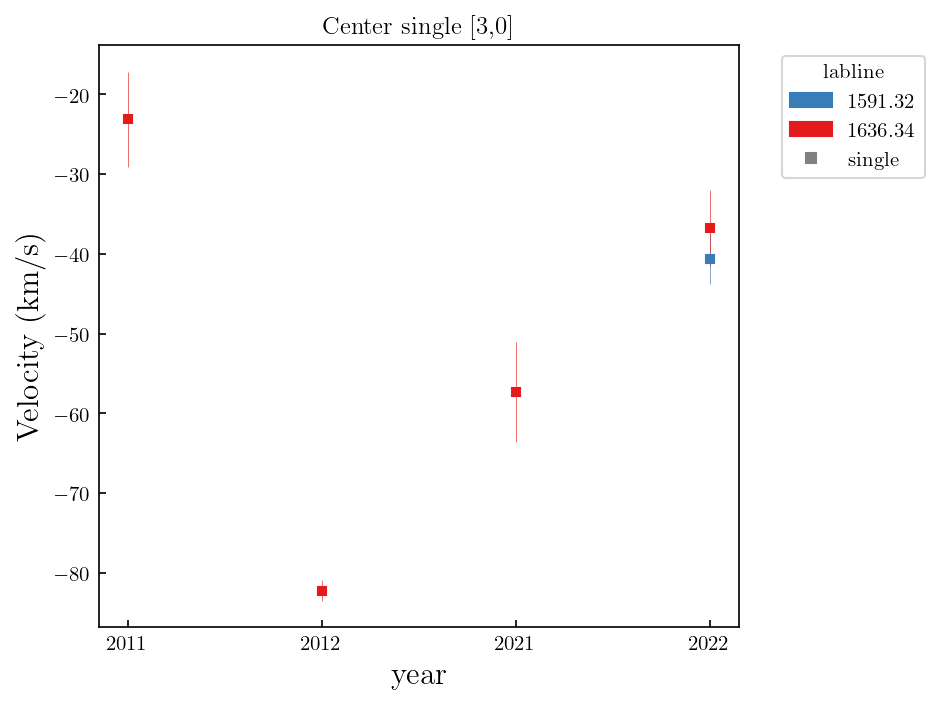

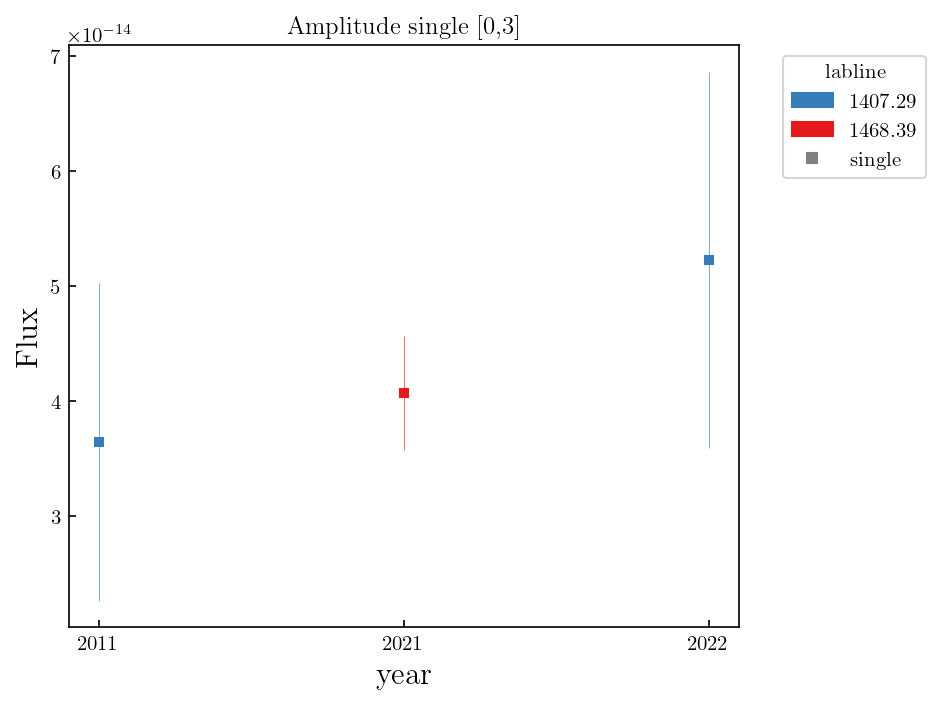

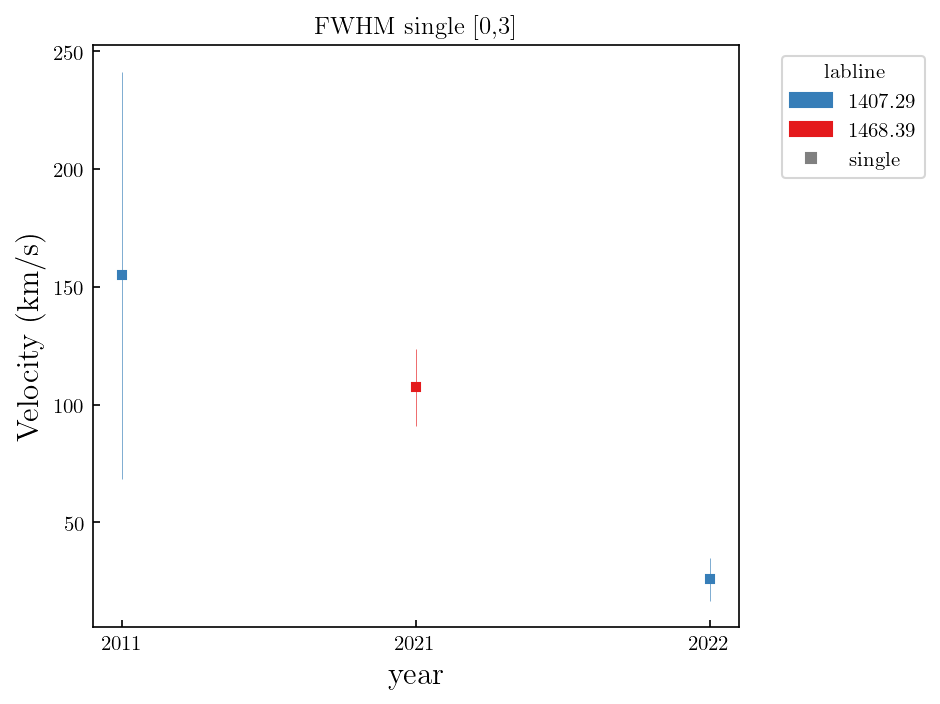

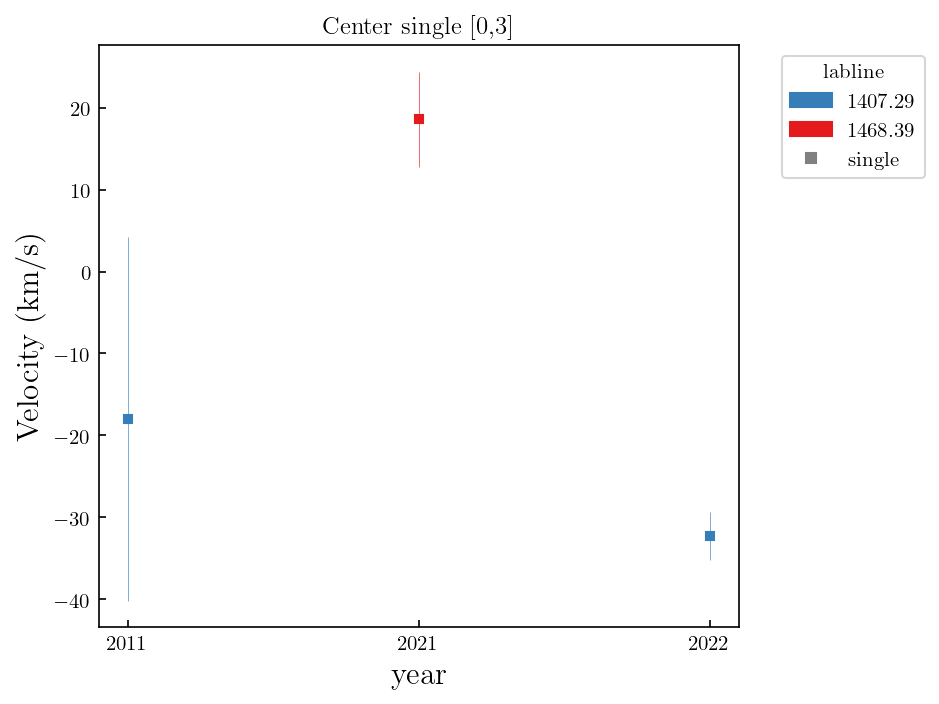

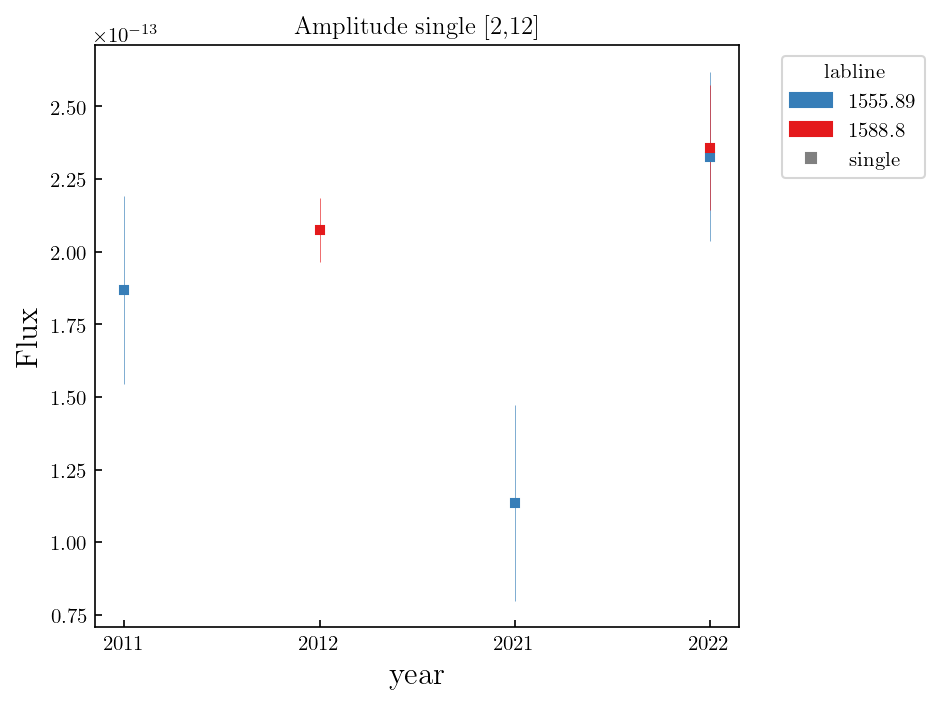

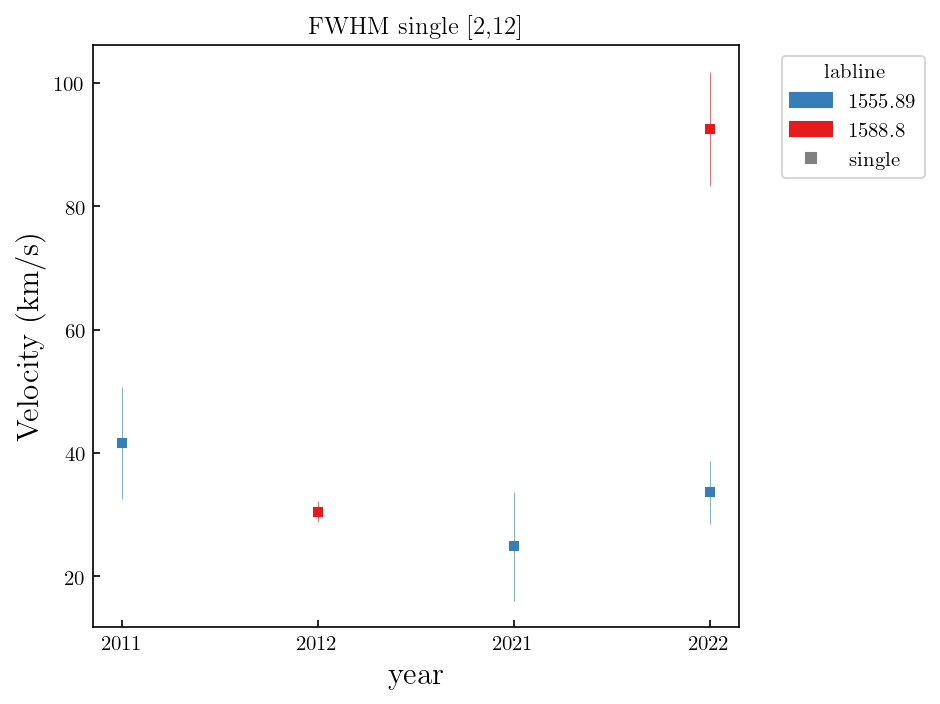

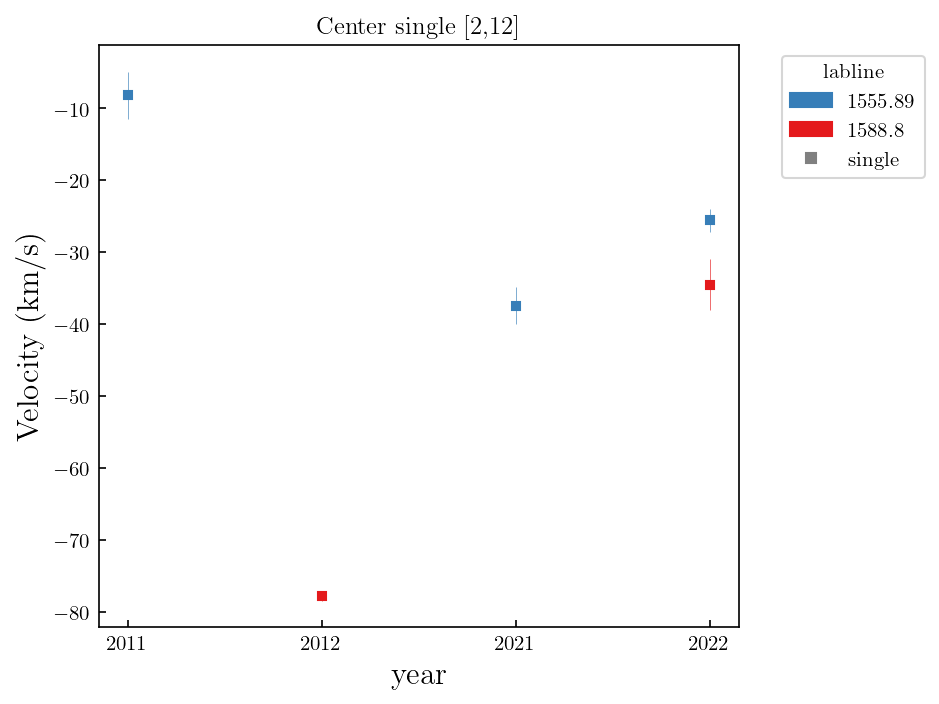

In [51]:
plot_progression_by_transition(SC_df, ['single'])
#plot_progression(BC_conf, ['NC', 'BC', 'single'])

# FWHM and Emitting Radius

In [57]:
def R_H2(fwhm):
    M_star = 0.55 * const.M_sun
    i = np.radians(16)
    #print(fwhm.to(u.km/u.s))
    v_rot = (fwhm).to(u.m/u.s)  # convert to SI for decompose()
    R = ((const.G * M_star) / ((np.sin(i)**2)*(v_rot**2))).decompose()
    return R.to(u.AU)

In [58]:
BC_conf['R_BC'] = np.nan
BC_conf['R_NC'] = np.nan

for transition in BC_conf['transition'].unique():
    sub_df = BC_conf[BC_conf['transition'] == transition]
    for labline in sub_df['labline'].unique():
        rows = sub_df[sub_df['labline'] == labline]
        for idx, row in rows.iterrows():
            sigma_BC = row['BC_params']['sigBC'][0]
            sigma_NC = row['NC_params']['sigNC'][0]
            fwhm_BC = FWHM(sigma_BC, labline)
            fwhm_NC = FWHM(sigma_NC, labline)
            BC_conf.loc[idx, 'R_BC'] = R_H2(fwhm_BC).value
            BC_conf.loc[idx, 'R_NC'] = R_H2(fwhm_NC).value

SC_df['R_SC'] = np.nan

for transition in SC_df['transition'].unique():
    sub_df = SC_df[SC_df['transition'] == transition]
    for labline in sub_df['labline'].unique():
        rows = sub_df[sub_df['labline'] == labline]
        for idx, row in rows.iterrows():
            sigma_SC = row['params1']['sig'][0]
            fwhm_SC = FWHM(sigma_SC, labline)
            SC_df.loc[idx, 'R_SC'] = R_H2(fwhm_SC).value

/tmp/ipykernel_6949/3098556514.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SC_df['R_SC'] = np.nan


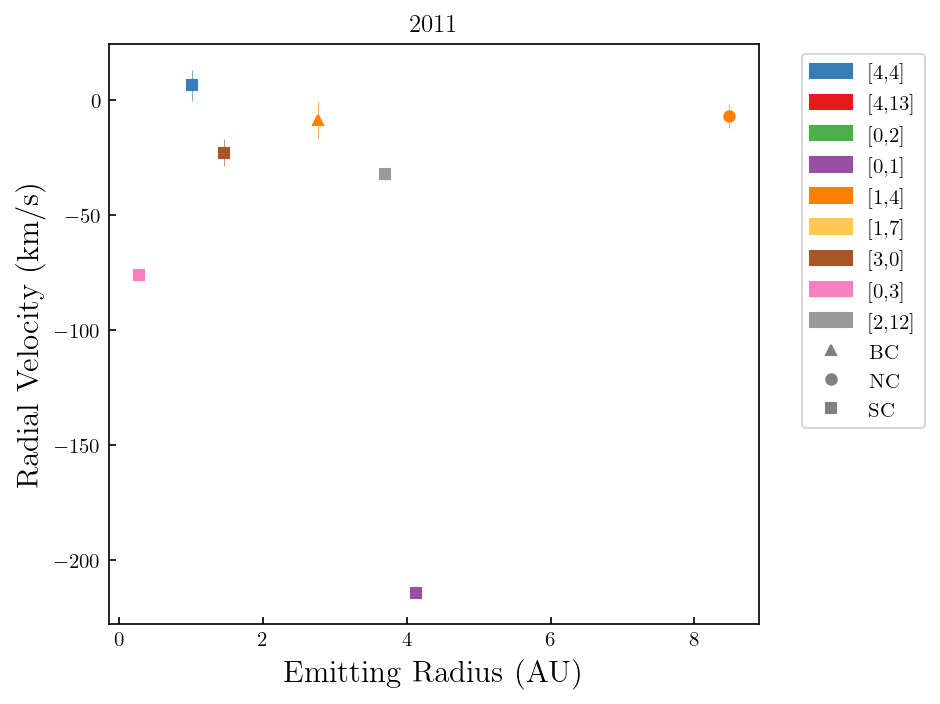

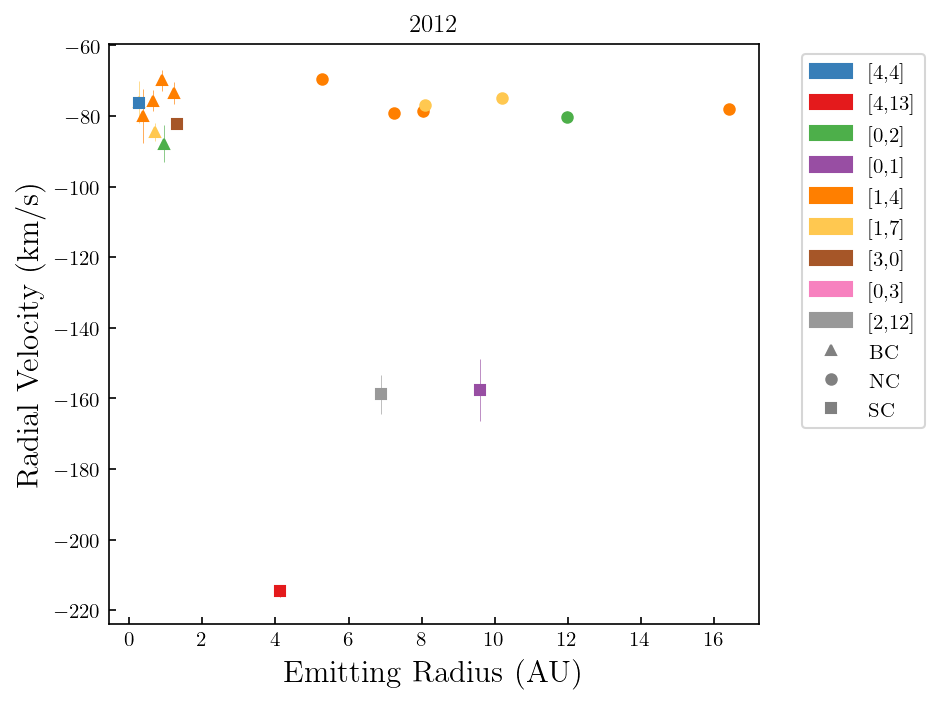

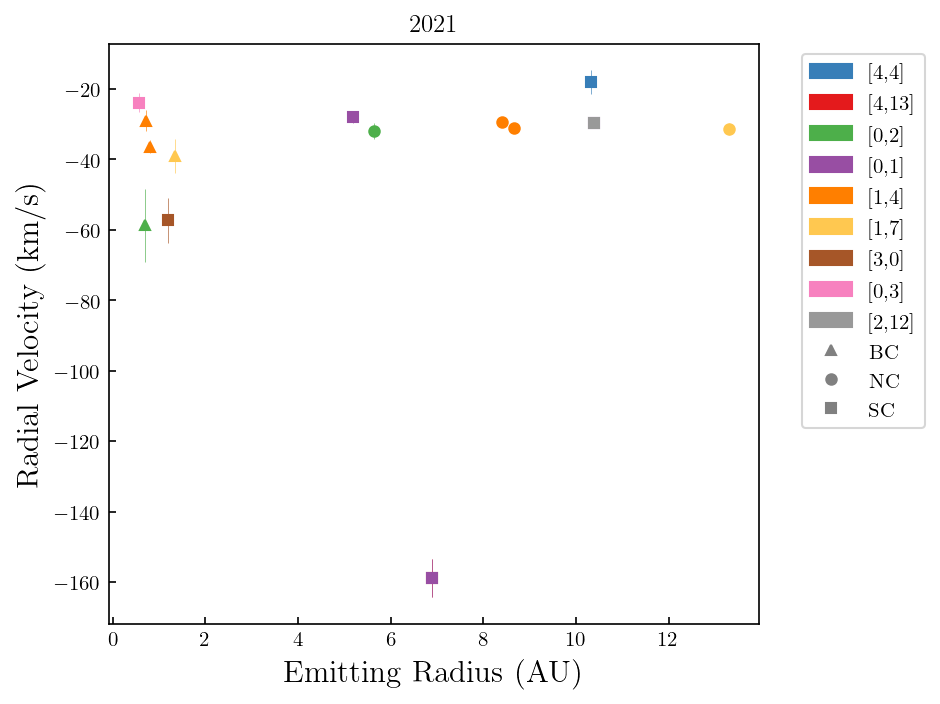

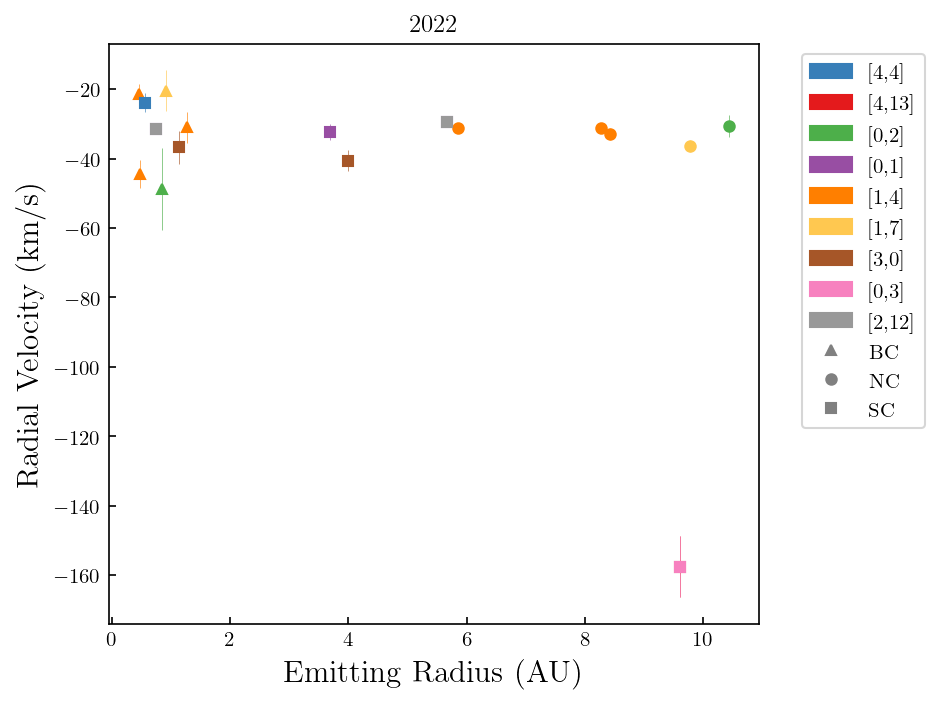

In [59]:
BCblueshift = [radial_velocity(i['cenBC'][0]*u.AA, labline).value for i, labline in zip(BC_conf['BC_params'], BC_conf['labline'])]
BCblueshift_err = [radial_velocity_error(i['cenBC'][1]*u.AA, labline).value for i, labline in zip(BC_conf['BC_params'], BC_conf['labline'])]

NCblueshift = [radial_velocity(i['cenNC'][0]*u.AA, labline).value for i, labline in zip(BC_conf['NC_params'], BC_conf['labline'])]
NCblueshift_err = [radial_velocity_error(i['cenNC'][1]*u.AA, labline).value for i, labline in zip(BC_conf['NC_params'], BC_conf['labline'])]

SCblueshift = [radial_velocity(i['cen'][0]*u.AA, labline).value for i, labline in zip(SC_df['params1'], SC_df['labline'])]
SCblueshift_err = [radial_velocity_error(i['cen'][1]*u.AA, labline).value for i, labline in zip(SC_df['params1'], SC_df['labline'])]

unique_transitions = all_df_pruned['transition'].unique()
color_map = {t: clrs[i] for i, t in enumerate(unique_transitions)}

component_labels = [
    plt.Line2D([0],[0], marker='^', color='gray', linestyle='', markersize=5, label='BC'),
    plt.Line2D([0],[0], marker='o', color='gray', linestyle='', markersize=5, label='NC'),
    plt.Line2D([0],[0], marker='s', color='gray', linestyle='', markersize=5, label='SC'),
]
transition_patches = [mpatches.Patch(color=color_map[t], label=t) for t in unique_transitions]

for year in sorted(BC_conf['year'].unique()):
    fig, ax = plt.subplots()

    # BC
    bc_year = BC_conf[BC_conf['year'] == year]
    for idx, (_, row) in enumerate(bc_year.iterrows()):
        orig_idx = list(BC_conf.index).index(row.name)
        c = color_map.get(row['transition'], 'gray')
        ax.errorbar(row['R_BC'], BCblueshift[orig_idx], yerr=BCblueshift_err[orig_idx],
                    marker='^', linestyle='', color=c, elinewidth=0.3, markersize=5)

    # NC
    nc_year = BC_conf[BC_conf['year'] == year]
    for _, row in nc_year.iterrows():
        orig_idx = list(BC_conf.index).index(row.name)
        c = color_map.get(row['transition'], 'gray')
        ax.errorbar(row['R_NC'], NCblueshift[orig_idx], yerr=NCblueshift_err[orig_idx],
                    marker='o', linestyle='', color=c, elinewidth=0.3, markersize=5)

    # SC
    sc_year = SC_df[SC_df['year'] == year]
    for _, row in sc_year.iterrows():
        orig_idx = list(SC_df.index).index(row.name)
        c = color_map.get(row['transition'], 'gray')
        ax.errorbar(row['R_SC'], SCblueshift[orig_idx], yerr=SCblueshift_err[orig_idx],
                    marker='s', linestyle='', color=c, elinewidth=0.3, markersize=5, alpha=1)

    ax.legend(handles=transition_patches + component_labels,
              bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_xlabel('Emitting Radius (AU)')
    ax.set_ylabel('Radial Velocity (km/s)')
    ax.set_title(f"{year}")
    plt.tight_layout()
    plt.show()

# Examine wing fit quality

In [25]:
BC_conf['transition'].unique()

array(['[0,2]', '[1,4]', '[1,7]'], dtype=object)

/tmp/ipykernel_6949/2763764757.py:21: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0, wspace=0)


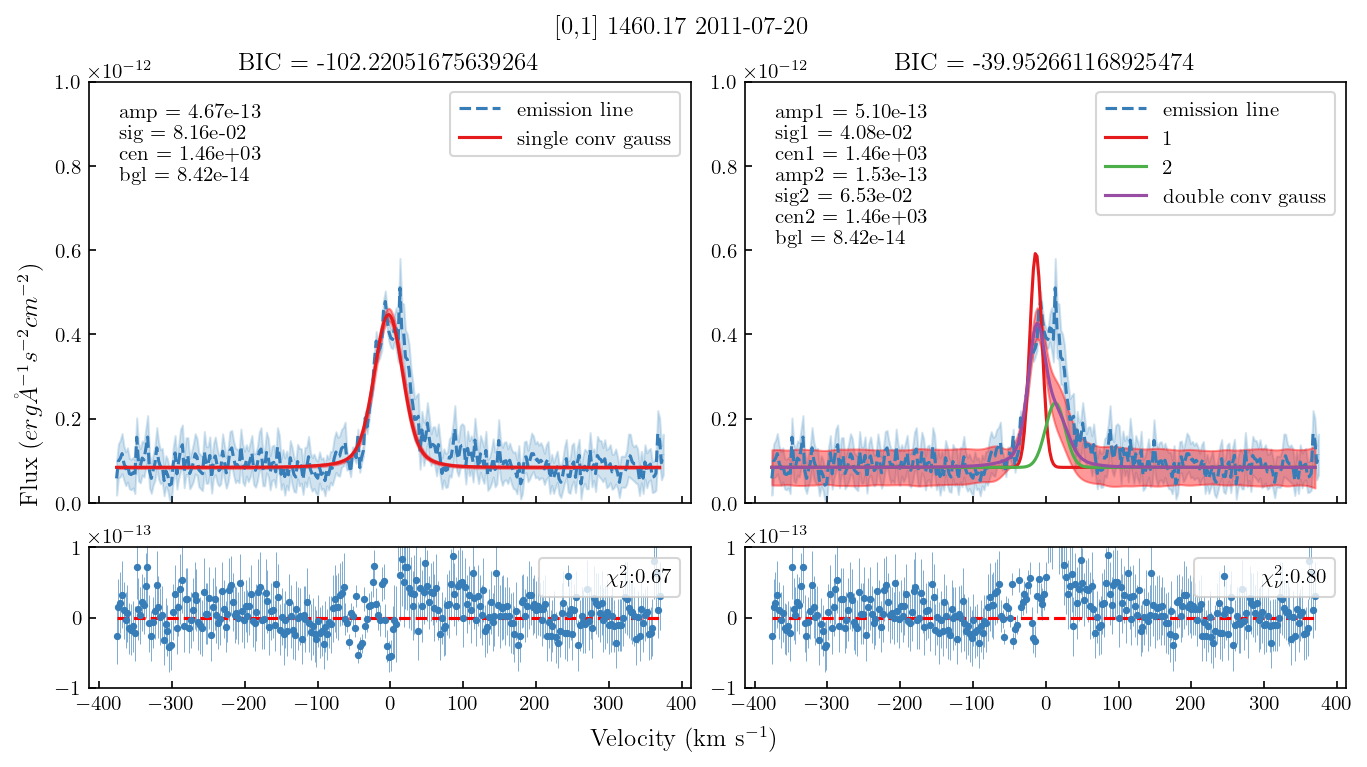

/tmp/ipykernel_6949/2763764757.py:21: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0, wspace=0)


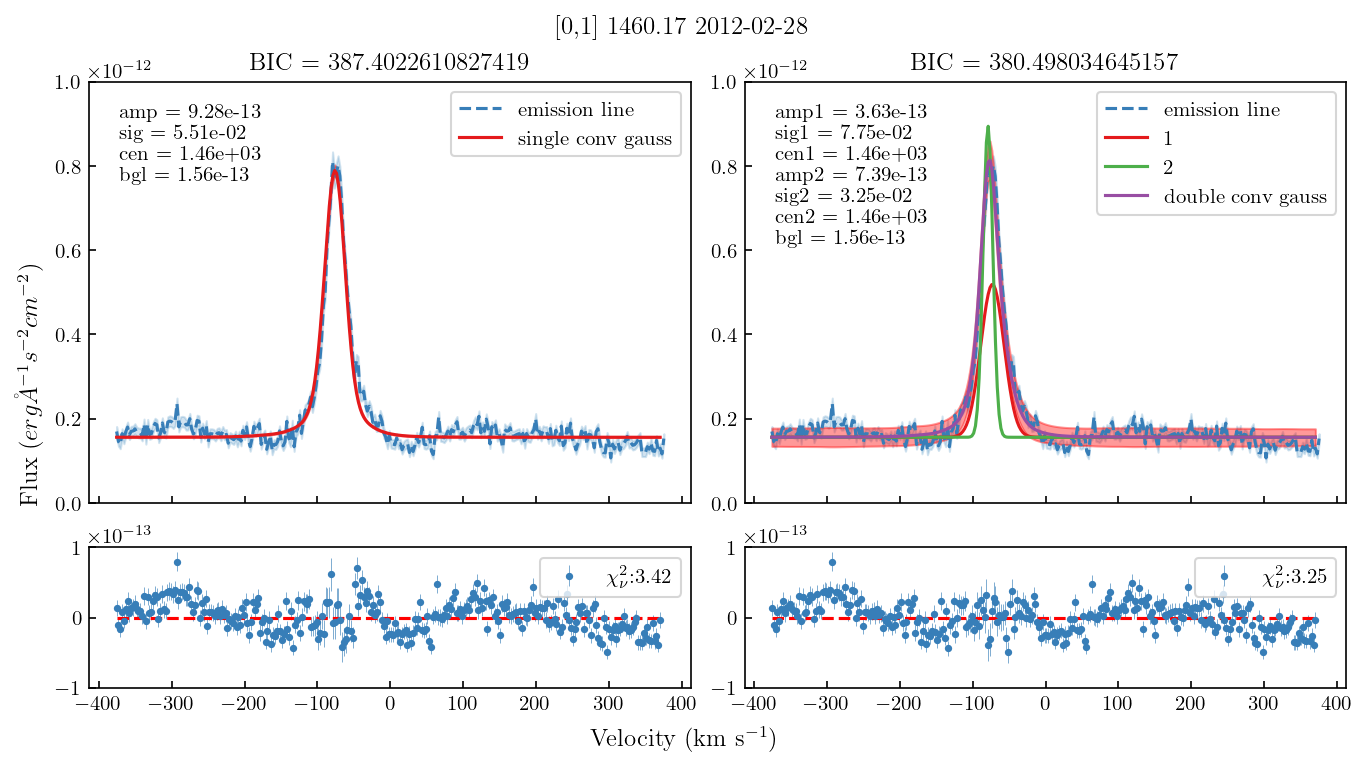

/tmp/ipykernel_6949/2763764757.py:21: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0, wspace=0)


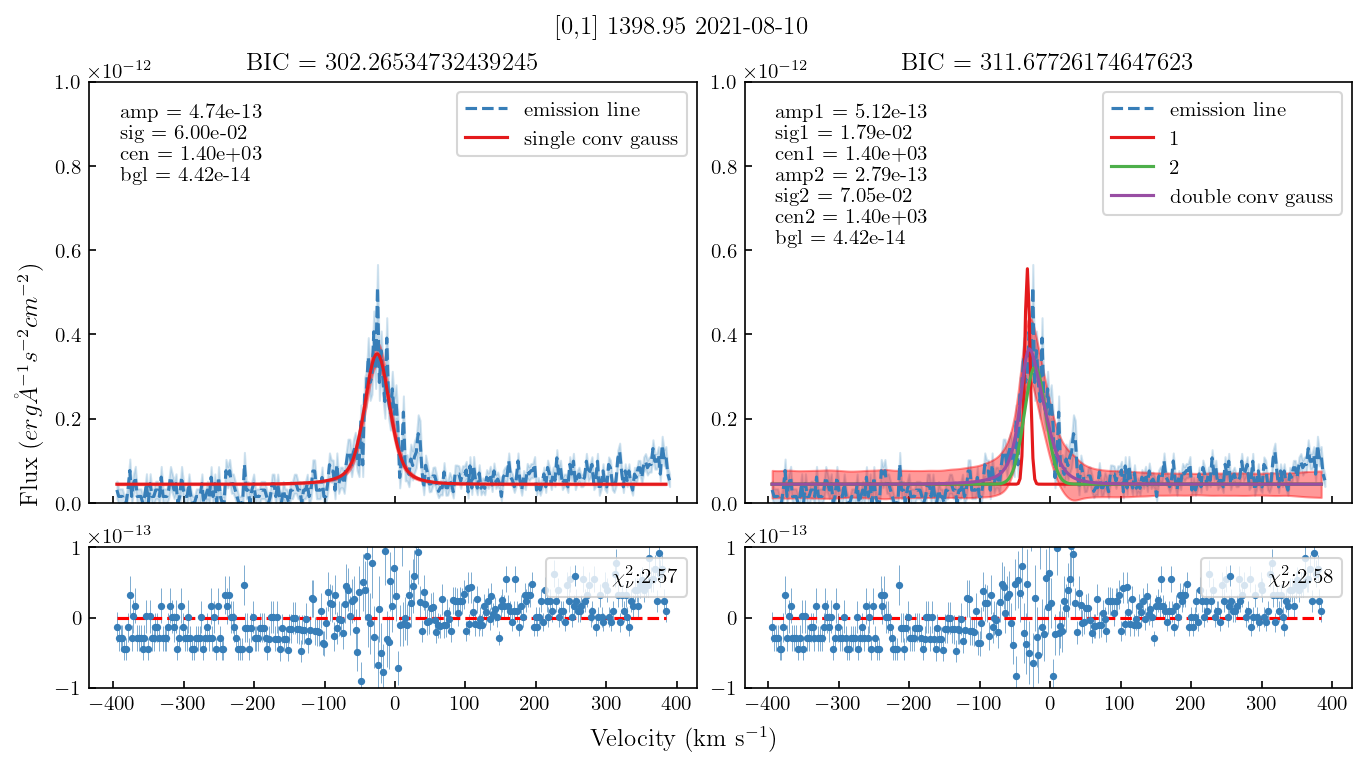

/tmp/ipykernel_6949/2763764757.py:21: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0, wspace=0)


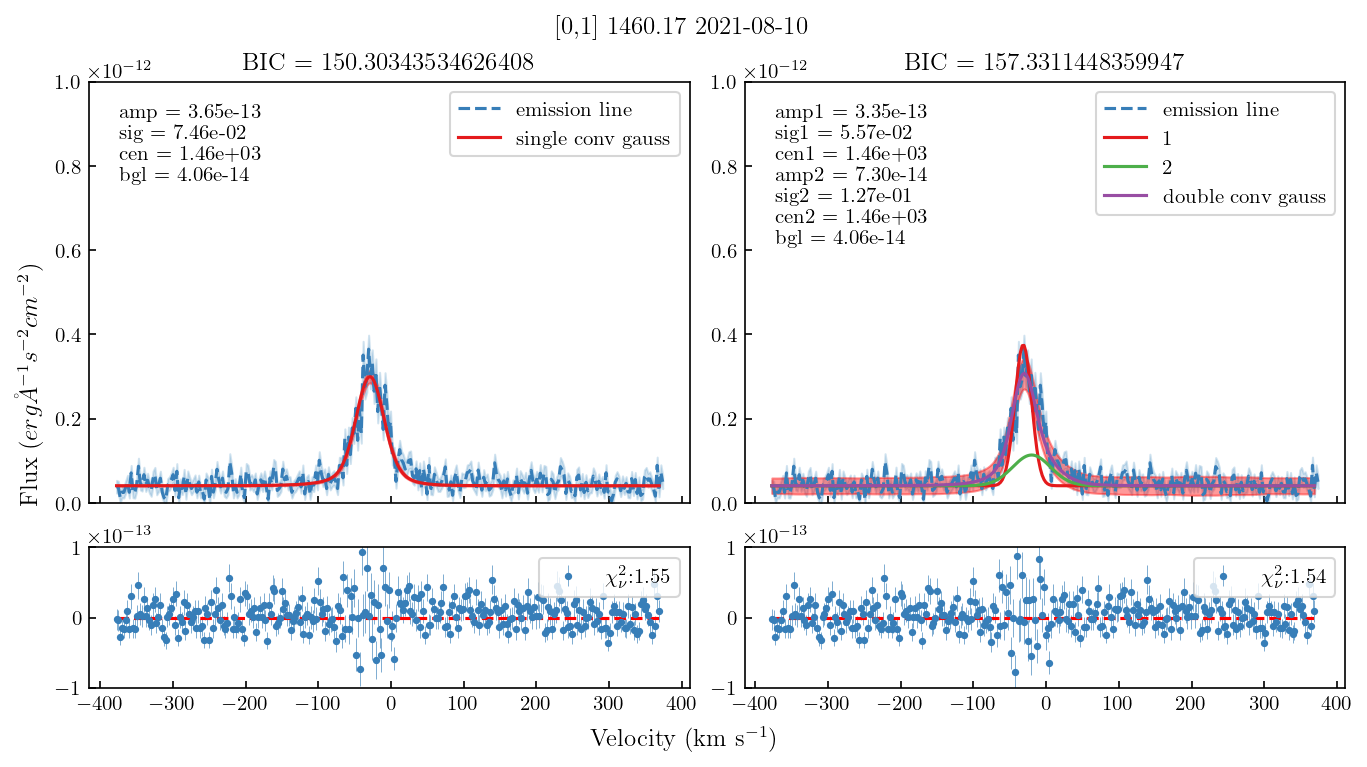

/tmp/ipykernel_6949/2763764757.py:21: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0, wspace=0)


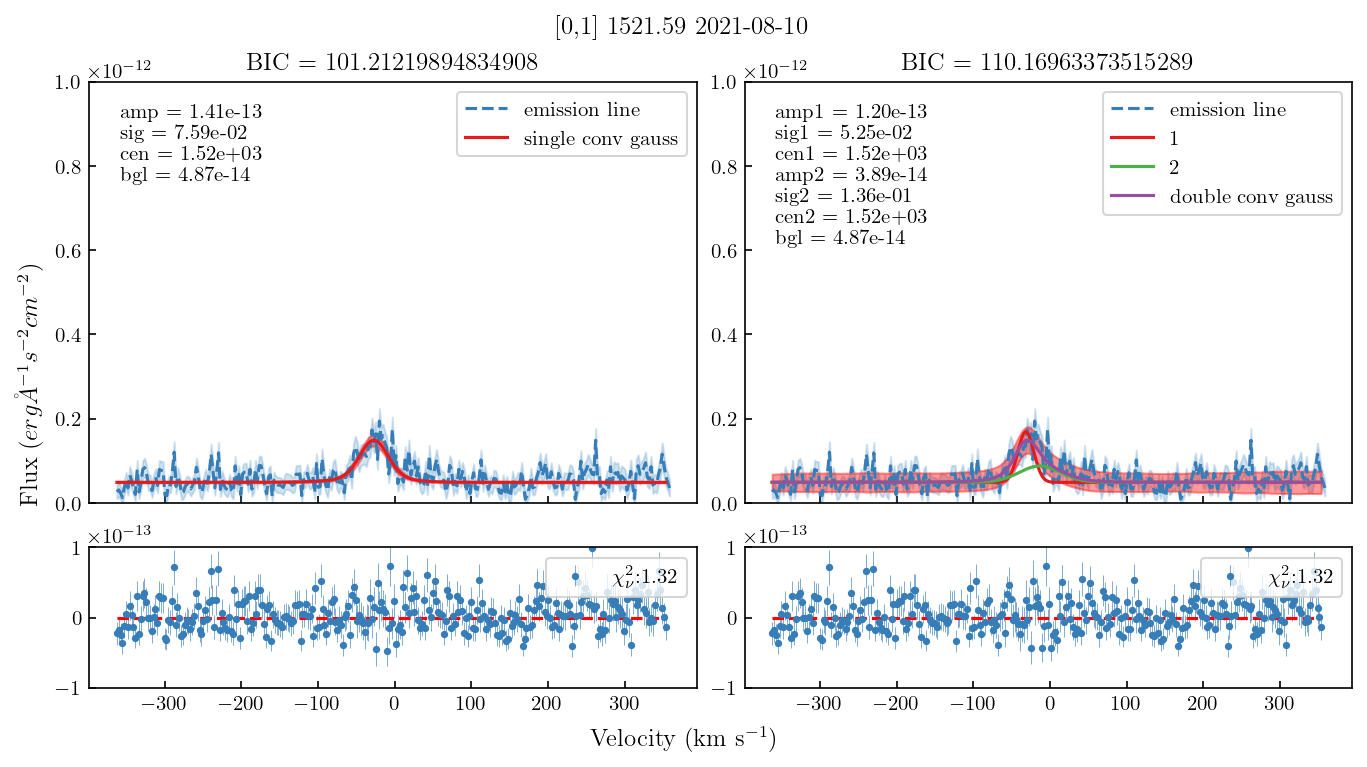

/tmp/ipykernel_6949/2763764757.py:21: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0, wspace=0)


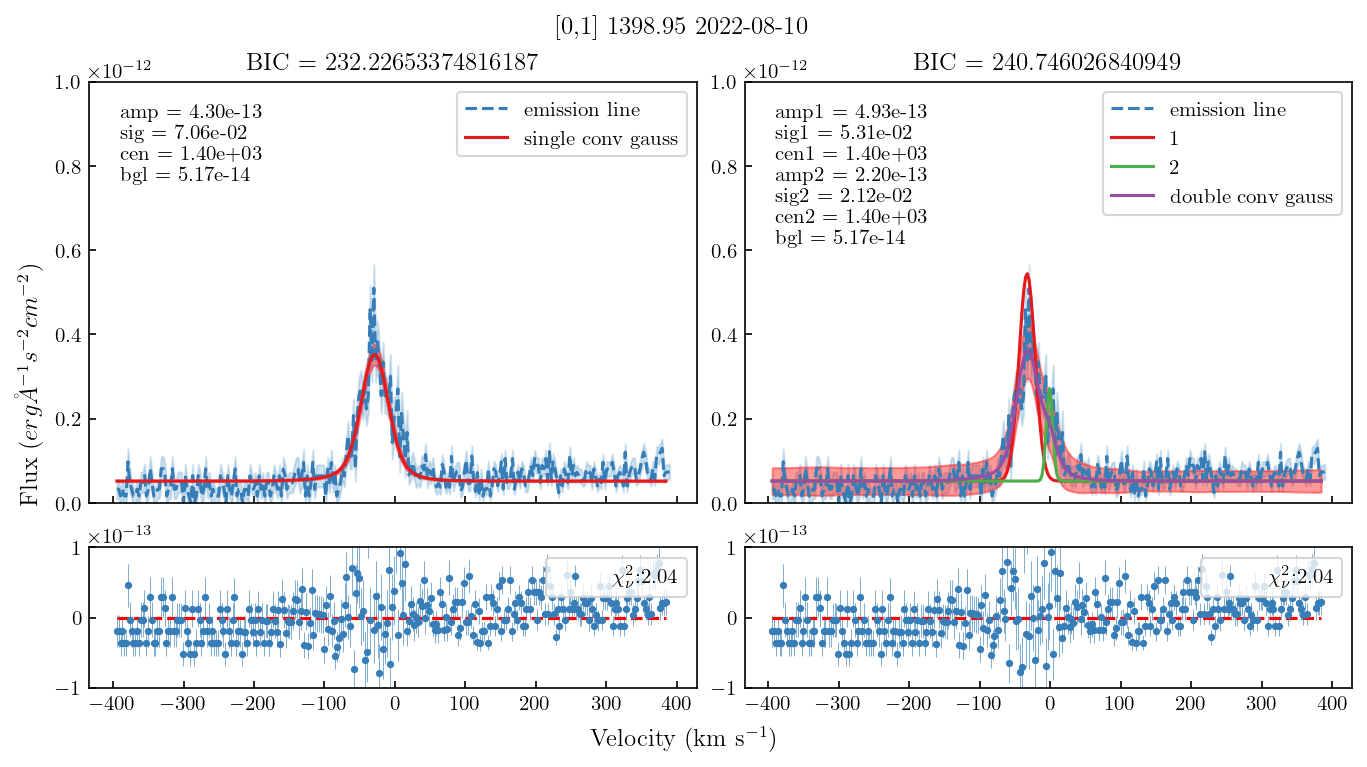

/tmp/ipykernel_6949/2763764757.py:21: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0, wspace=0)


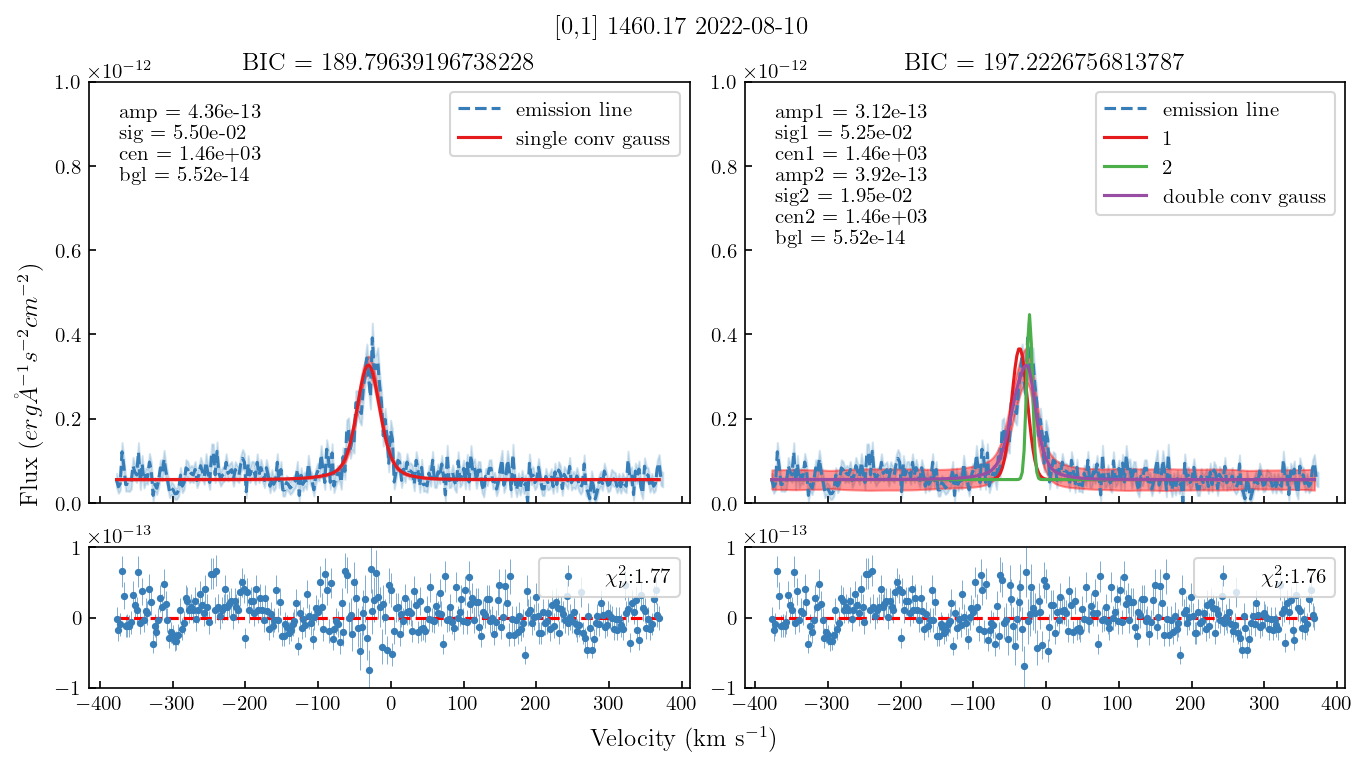

/tmp/ipykernel_6949/2763764757.py:21: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0, wspace=0)


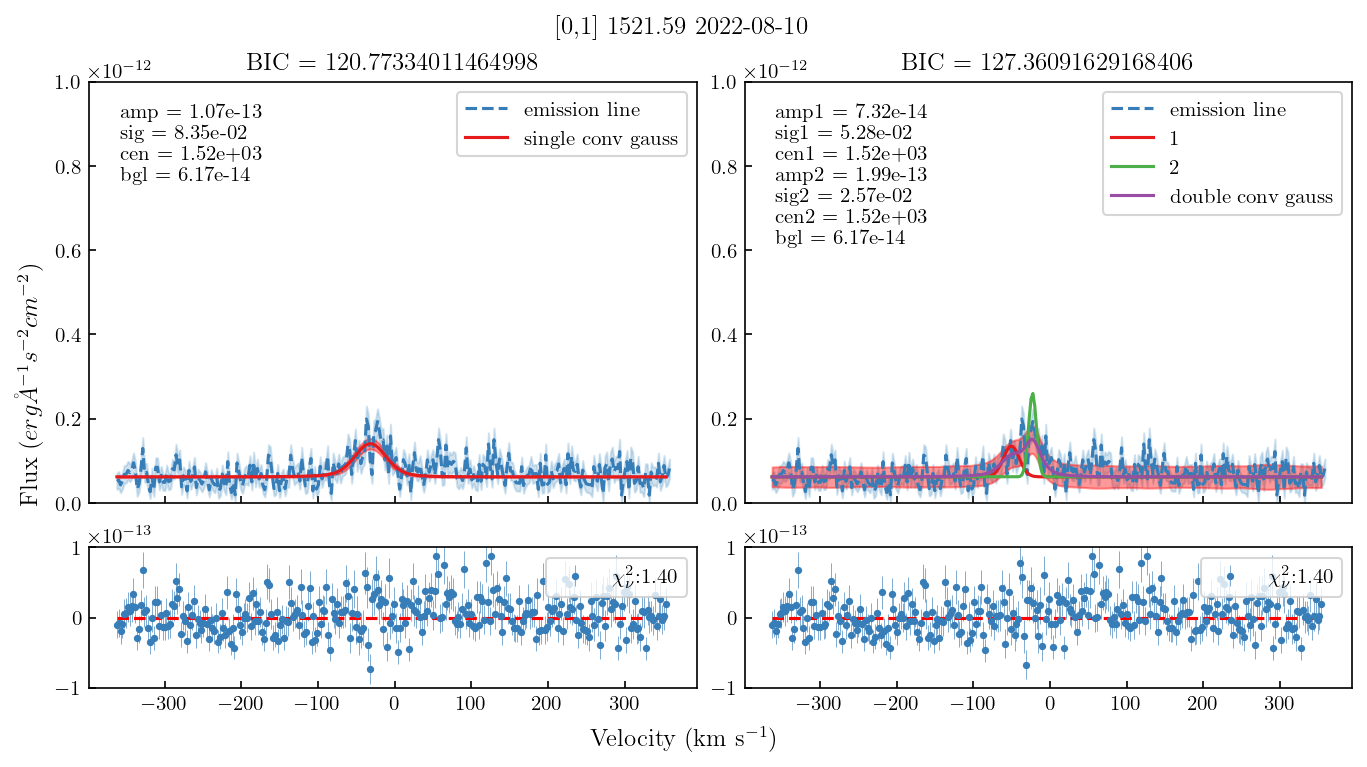

In [53]:
# for transit in BC_conf['transition'].unique():
plot_fits(SC_df, transition='[0,1]', plot_vel=True)

In [19]:
#0 is bad, 1 is good
wing_fit_quality = {
    (1463.83, '2011-07-20'): 0,
    (1463.83, '2021-08-10'): 1,
    (1463.83, '2022-08-10'): 1,
    (1463.83, '2012-02-28'): 1,
    (1446.12, '2011-07-20'): 0,
    (1446.12, '2012-02-28'): 1,
    (1446.12, '2022-08-10'): 1,
    (1489.57, '2011-07-20'): 0,
    (1489.57, '2012-02-28'): 0,
    (1489.57, '2021-08-10'): 1,
    (1489.57, '2022-08-10'): 1,
    (1504.76, '2011-07-20'): 1,
    (1504.76, '2012-02-28'): 1,
    (1504.76, '2021-08-10'): 1,
    (1504.76, '2022-08-10'): 1,
    (1431.01, '2012-02-28'): 1,
    (1500.45, '2011-07-20'): 1,
    (1500.45, '2021-08-10'): 1,
    (1500.45, '2012-02-28'): 0,
    (1500.45, '2022-08-10'): 1,
    (1467.08, '2012-02-28'): 1,
}

BC_diff['wing_fit_quality'] = BC_diff.apply(
    lambda row: wing_fit_quality.get((row['labline'], str(row['obsdate'])), None), axis=1
)